**Resource Efficient Graph Neural Networks for Cascading Failure Risk Prediction in Smart Grids: Comparison of Edge Aware GNNs, Graph Attention Networks, NAS, Threshold Tuning, and Structured Pruning**

**Course: Intelligent Monitoring and Control Systems**

Goal: Building an intelligent monitoring system that predicts cascading failure risk in smart grids.

The project compares the following models:

-FCNN baseline: a non-graph baseline that uses aggregated grid features without explicitly modelling the power grid topology.

-Edge aware GCN style baseline: a non aattention graph neural network that uses graph topology, node features, and edge features. This baseline is included to test wether edge aware message passing alone is sufficient for cascading failure prediction.

-Manual GAT: a manually defined graph attention network using graph topology, node features, edge features, and attention mechanisms.

-NAS-GAT: a graph attention network selected through a contrained neural architecture search proceadure. The goal is to test wether architecture search can improve the attention based model.

-Head pruned NAS-GAT: a compressed version of the NAS-GAT obtained through structured attention head pruning and fine tuning. This model is used to study the trade off between predictive performance, model size, and inference latency.

The dataset is PowerGraph, using graph level cascading failure task.


## 0. Notes before running

Since the PowerGraph cascading failure archive is large, I started with GRID_NAME = "ieee24" and FAST_RUN = True so the notebook could be tested quicly in Colab. For the final result I cahnaged FAST_RUN = False to use more data and it took longer to train.


## 1. Installing packages



In [1]:
%%capture
# to hide the putput of this cell
!pip install -q torch-geometric mat73 scikit-learn pandas matplotlib
# !pip install -> running terminal command from inside notebook
# -q -> quiet mode -> reducing the installation output
# torch-geometric -> library for graph neural networks built on PyTorch
# mat73 -> For loading MATLAB .mat files, especially version 7.3 files
# scikit-learn -> ML tools, metrics, preprocessing, train/test split
# pandas -> Dataframes and data analysis
# matplotlib -> Plotting and visualization

## 2. Imports & Settings

Preparing the environment for graph neural network training pipeline

In [2]:
# Standard python libraries
import os, random, time
from pathlib import Path  # To handle files and folders in a clean way

import mat73
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch libraries for deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch geometric classes for graph data handling
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# Graph neural network layers and graph level pooling functions
# GCNConv -> graph convolution network layer
# GATConv -> graph attention network layer
# GINEConv -> graph isomorphism network layer with edge features -> designed to distinguish graph structures effectively, especially when edge features are used
# Note: In graph theory, 2 graphs are isomorphic if they have the same structure even if node names or positions are different
# Global pool libraries ->for aggregating node embeddings into a graph level embedding
from torch_geometric.nn import GCNConv, GATConv, GINEConv, global_mean_pool, global_max_pool, global_add_pool

# Scikit-learn utilities for splitting data and evaluating model performance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

# Fixed seed to make the project reproducible
SEED = 42

# Setting the random seed for Python, NumPy, and PyTorch -> reproducibilty by ensuring that random operations, such as data shuffling and weight initialization, behave in the same way each time the notbook runs
def seed_everything(seed = 42):

    random.seed(seed)   # Seed for Python's built in random module
    np.random.seed(seed)  # Seed for NumPy random operations
    torch.manual_seed(seed)  # Seed for PyTorch operations on CPU
    torch.cuda.manual_seed_all(seed)  # Seed for PyTorch operations on all GPUs

# Applying the fixed seed
seed_everything(SEED)

# Selecting the GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Priniting the selected computation device
print("Device:", device)

Device: cpu


## 3. Downloading the PowerGraph cascading failure data

The archive contains the cascading failure simulation datasets for IEEE-24, IEEE-39, IEEE-118, and UK grids. This cell downloads, diagnoses, and extract the data.

In [3]:
import zipfile, tarfile  # Libraries used to extract compressed archived files
import requests  # For downloading files from the internet
import shutil  # General file utilities

DATA_DIR = Path("/content/powergraph")  # Folder where the dataset will be stored
ARCHIVE_PATH = Path("/content/powergraph_downloaded_file")  # Temporary path where the downloaded files will be saved

DATA_DIR.mkdir(parents = True, exist_ok = True)  # Creating the dataset folder if it doesnt already exist


FILE_ID = "46619158"   # Official PowerGraph Figshare file ID from GitHub README
# Posssible Figshare download urls -> cheking both because sometimes one url may fail or redirect incorrectly.
URLS = [f"https://figshare.com/ndownloader/files/{FILE_ID}", f"https://ndownloader.figshare.com/files/{FILE_ID}", ]


# Starting from a clean state by deleting any previuosly downloaded file
if ARCHIVE_PATH.exists():
    ARCHIVE_PATH.unlink()

print("Downloading PowerGraph file...")

download_success = False  # Boolean flag -> To check wether the download was successful or not

# trying each possible download url
for url in URLS:
    print("\nTrying:", url)

    try:
      # downloading the file usinf streamin mode -> stream = True -> avoids loading the whole file into memory at onces
        with requests.get(url, stream = True, allow_redirects = True, timeout = 180, headers = {"User-Agent": "Mozilla/5.0"}) as r:
            # Prinitng diagnostic information about the server resonse
            print("HTTP status:", r.status_code)
            print("Content Type:", r.headers.get("Content-Type"))
            print("Content Length:", r.headers.get("Content-Length"))

            # Continuing to the next url if this one did not return a valid response
            if r.status_code not in [200]:
                print("This URL did not return the file directly.")
                continue

            # Saving the downloaded content in chunk of 1 MB
            with open(ARCHIVE_PATH, "wb") as f:
                for chunk in r.iter_content(chunk_size = 1024 * 1024):
                    if chunk:
                        f.write(chunk)

        # Checking the downloaded file size in MB
        size_mb = ARCHIVE_PATH.stat().st_size / (1024 * 1024)
        print(f"Dpwnloaded size: {size_mb:.2f} MB")

        # If the file is larger that 1 MB we assume that the download is valid
        if size_mb > 1:
            download_success = True
            break

    except Exception as e:
        # Printing the error if the download fails
        print("Download failed:", e)

# Stopping the noetbook if any usable file was downloaded
if not download_success:
    raise RuntimeError("Download failed. Figshare did not return a usable file.")




# Diagnosing file type
print("\nChecking doenloaded file type...")

# Reading the first byte of the file -> to identify wether the file is really an archive or sth else.
with open(ARCHIVE_PATH, "rb") as f:
    first_bytes = f.read(32)

print("First 32 bytes:", first_bytes)

# checking wether the downloaded file is a TAR or ZIP archive
print("Is tar archive:", tarfile.is_tarfile(ARCHIVE_PATH))
print("Is zip archive:", zipfile.is_zipfile(ARCHIVE_PATH))



# Extracting depending on the real file type
EXTRACT_DIR = DATA_DIR / "raw"   # The folder where the extracted files will be stored
EXTRACT_DIR.mkdir(parents = True, exist_ok = True)

# extracting the file if its a TAR archive
if tarfile.is_tarfile(ARCHIVE_PATH):
    print("\nExtracting as TAR archive...")
    with tarfile.open(ARCHIVE_PATH, "r:*") as tar:
        tar.extractall(EXTRACT_DIR)

# extracting the file if its a ZIP archive
elif zipfile.is_zipfile(ARCHIVE_PATH):
    print("\nExtracting as ZIP archive...")
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

# If the file is neither TAR nor ZIP, print a previwe and stop
else:
    print("\nThe file is neither TAR nor ZIP.")
    print("I will peint the first part of the file to understand what was downloaded.")

    with open(ARCHIVE_PATH, "rb") as f:
        preview = f.read(500)

    print(preview)

    raise RuntimeError("The downloaded file is not an archive. It may be an HTML response or another Figshare temporary response.")

    print("\nExtraction completed.")



# Searching inside the extracted folder for .mat files
mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

print("\nNumber of .mat files found:", len(mat_files))

# Prinitng the first 50 .mat files found
print("\nFirst 50 .mat files:")
for p in mat_files[:50]:
    print(p.relative_to(EXTRACT_DIR))

# List of expected files in PowerGraph dataset
expected_files = ["blist.mat", "Bf.mat", "Ef.mat", "of_bi.mat", "of_reg.mat", "of_mc.mat", "exp.mat", ]
# Bf -> Bus features, Ef -> edge feature, blist -> network topology (later become edge_index), of_bi - > output labels for binary classification
# of_reg -> regression targets, of_mc -> mulriclass targets, exp ->  explanation
# Collecting only the file names, ignoring the full folder path
found_names = {p.name for p in mat_files}

# Checking whether each expected file was found
print("\nExpected files check:")
for name in expected_files:
    print(name, "->", name in found_names)


Trying: https://figshare.com/ndownloader/files/46619158
HTTP status: 202
Content Type: text/html; charset=UTF-8
Content Length: 0
This URL did not return the file directly.

Trying: https://ndownloader.figshare.com/files/46619158
HTTP status: 200
Content Type: application/zip
Content Length: 61628977
Dpwnloaded size: 58.77 MB

Checking doenloaded file type...
First 32 bytes: b'PK\x03\x04\x14\x00\x00\x00\x00\x004w\xbcX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x08\x00\x00\x00ie'
Is tar archive: False
Is zip archive: True

Extracting as ZIP archive...

Number of .mat files found: 32

First 50 .mat files:
ieee118/ieee118/raw/Bf.mat
ieee118/ieee118/raw/Ef.mat
ieee118/ieee118/raw/Ef_nc.mat
ieee118/ieee118/raw/blist.mat
ieee118/ieee118/raw/exp.mat
ieee118/ieee118/raw/of_bi.mat
ieee118/ieee118/raw/of_mc.mat
ieee118/ieee118/raw/of_reg.mat
ieee24/ieee24/raw/Bf.mat
ieee24/ieee24/raw/Ef.mat
ieee24/ieee24/raw/Ef_nc.mat
ieee24/ieee24/raw/blist.mat
ieee24/ieee24/raw/exp.mat
ieee24/ieee24/raw/

## 4. Finding the selected grid raw folder



In [4]:
# starting with ieee24 because its the smallest
GRID_NAME = "ieee24"

# These are the filse that must be present in a vaid grid folder
REQUIRED_FILES =  {"blist.mat", "Bf.mat", "Ef.mat", "of_bi.mat", "of_reg.mat", "of_mc.mat", "exp.mat",}

# This function searches inside the extracted dataset folder and finds the folder corresponding to the selected grid ->  here ieee24
def find_grid_raw_folder(base_dir, grid_name):

    # Converting base directory to a path object for easier file handling
    base_dir = Path(base_dir)
    candidates = []  # Empty list for storing folders that  contain all required dataset files

    # Searching for every file named Bf.mat -> its used as a marker to identify possible grid folders
    for path in base_dir.rglob("Bf.mat"):

        folder = path.parent  # Getting the folder containing Bf.mat file
        files_here = {p.name for p in folder.iterdir() if p.is_file()}  # Collecting all file names inside this folder
        # Checking if this folder contains all required PowerGrapgh files
        if REQUIRED_FILES.issubset(files_here):
            candidates.append(folder)

    # Printing all folders that look like valid grid folders
    print("Candidate folders:")
    for c in candidates:
        print(" -", c)

    # Keeping only the candidate folders whose path contains the selected grid name
    selected = [c for c in candidates if grid_name.lower() in str(c).lower()]

    # If no matching folder is found, stop the code and show an error
    if len(selected) == 0:
        raise FileNotFoundError(f"No folder found for grid '{grid_name}'. Check GRID_NAME or the extraction folder.")

    return selected[0]  # Returning the first matching folder

# Finding the raw data folder for the selected grid using the function above
RAW_DIR = find_grid_raw_folder(EXTRACT_DIR, GRID_NAME)

# Printing the selected grid and folder path
print("\nSelected grid:", GRID_NAME)
print("Selected folder:", RAW_DIR)

Candidate folders:
 - /content/powergraph/raw/ieee39/ieee39/raw
 - /content/powergraph/raw/ieee118/ieee118/raw
 - /content/powergraph/raw/ieee24/ieee24/raw
 - /content/powergraph/raw/uk/uk/raw

Selected grid: ieee24
Selected folder: /content/powergraph/raw/ieee24/ieee24/raw


## 5. Converting .mat files into graph objects

Here each sample becomes one PyTorch geometric graph.
- x: node features -> net active power, net apparent power, voltage magnitude
- edge_attr: edge features -> active flow, reactive flow, reactance, line rating
- edge_index: grid topology
- y_class: binary cascade label
- y_reg: DNS severity label
- edge_mask: explanation mask for failed/cascade edges

I duplicated lines in both directions because message passing uses directed edges.

In [5]:
# Helper functions for MATLAB data


# MATLAB data loaded in python can contain nested object arrays, lists, or single item containers. This function unwraps those nested containers and returns the actual usful data inside.
def unwrap_mat_item(item):

    # If item is a Numpy object array with only one element, extract that single element
    while isinstance(item, np.ndarray) and item.dtype == object and item.size == 1:
        item = item.item()

    # If item is still an object array, take the first element
    if isinstance(item, np.ndarray) and item.dtype == object:
        item = item[0]

    # If item is a list or a tuple, take the first element
    if isinstance(item, (list, tuple)):
        item = item[0]
    return item


# This function gets the i-th sample from a MATLAB loaded container, unwraps it and converts it into a NumPy array
def get_sample(container, i):
    return np.array(unwrap_mat_item(container[i]))


# This function converts a raw MATLAB label into an integer class label. If the label is one hot encoded, uses the argmax. Otherwise converts the scaler value directly into an integere
def to_binary_label(raw_label):
    y = np.array(raw_label).squeeze()  # Converting label to NumPy array and removing extra dimension
    if y.ndim > 0 and y.size > 1:  # If the label has multiple values, assume it is one hot encoded
        return int(np.argmax(y))
    return int(float(y))  # Otherwise converting the scaler label to integere


# This function converts a raw MATLAB regression label into a python float
def to_regression_label(raw_label):
    y = np.array(raw_label).squeeze()  # Converting label to NumPy array and removing extra dimension
    if y.ndim > 0:  # If it is still an array, take the first value
        return float(y.reshape(-1)[0])
    return float(y)  # Otherwise converting the scaler directly


# This function gets explanation indices for the i-th sample. MATLAB uses 1 based indexing, while python uses 0 based indexing -> this function subtracts 1 from the indices
def get_explanation_indices(exp_container, i):
    item = unwrap_mat_item(exp_container[i])  # Extracting an unwraping the i-th explanatin item

    # If there is no explanation, return an empty integer array
    if item is None:
        return np.array([], dtype = int)
    item = np.array(item)  # Converting the explanation iten into a NumPy array

    # If the explanation array is empty, return an empty integer array
    if item.size == 0:
        return np.array([], dtype = int)

    return item.astype(int).reshape(-1) - 1  # Converting MATLAB 1 based indices to python 0 based indices

## 6. Loading raw PowerGraph files and exploring the data

In [6]:
print("Loading .mat files...")

edge_order_mat = mat73.loadmat(str(RAW_DIR / "blist.mat"))  # Loading the file containing the original grid branch/edge connections
binary_mat = mat73.loadmat(str(RAW_DIR / "of_bi.mat"))  # Loading the binary classification labels
reg_mat = mat73.loadmat(str(RAW_DIR / "of_reg.mat"))  # Loading the regression labels
node_mat = mat73.loadmat(str(RAW_DIR / "Bf.mat"))  # Loading the node features
edge_mat = mat73.loadmat(str(RAW_DIR / "Ef.mat"))  # Loading the edge features
exp_mat = mat73.loadmat(str(RAW_DIR / "exp.mat"))  # Loading the explanaitions/ground truth important edges or indices

# Extracting the branch list from the MATLAB file.
edge_order = np.array(edge_order_mat["bList"], dtype = np.int64) - 1  # Converting MATLAB 1 based indices to python 0 based indices
node_features_all = node_mat["B_f_tot"]  # Extracting all node features for all samples
edge_features_all = edge_mat["E_f_post"]  # Extracting all edge features for all samples
binary_labels_all = binary_mat["output_features"]  # Extracting all binary labels for classification
reg_labels_all = reg_mat["dns_MW"]  # Extracting all regression labels, related to demand not served  in MW
exp_all = exp_mat["explainations"]  # Extracting all explanation label/indices

print("Number of samples:", len(node_features_all))   # Printing the total number of graph samples available
print("Number of original branches:", len(edge_order))  # Printing the total number of original branches/edges in the selected power grid

Loading .mat files...
Number of samples: 21500
Number of original branches: 38


In [7]:
# Data explorationK structure, features, labels, and graph meaning

# This is used to understand what the PowerGraph cascading failure dataset contains before builing the PuTorch geometric graphs.
# The goal is to inspect:
# - how many simulated grid scenarios are available
# - how many buses aand branches are present
# - how many node and edge features are available
# - what the classification and regression labels look like
# - how the graph topo;ogy is represented
# - whether failed or unavailable edges appear in the raw edge features

print("=" * 80)
print("POWERGRAPH RAW DATA EXPLORATION")
print("=" * 80)


# 1. Basic selected grid info
print("\n1. Selected grid info")
print("-" * 80)
print("Selected grid name:", GRID_NAME)
print("Raw data folder:", RAW_DIR)

# edge_order should contain the physical graph topology. It normally has shape [number_of_edges, 2], where each row is one branch: source bus -> target bus
print("\nedge_order shape:", edge_order.shape)

num_physical_edges = edge_order.shape[0]
num_buses_from_edges = int(edge_order.max()) + 1

print("Number of physical branches/edges:", num_physical_edges)
print("Estimated no. of buses from edge_index:", num_buses_from_edges)

print("\nFirst 10 physical edges from edge_order:")
display(pd.DataFrame(edge_order[:10], columns = ["source_bus", "target_bus"]))


# 2. Raw feature array shapes
print("\n2. Raw feature array shapes")
print("-" * 80)

print("node_features_all type:", type(node_features_all))
print("edge_features_all type:", type(edge_features_all))
print("binary_labels_all type:", type(binary_labels_all))
print("reg_labels_all type:", type(reg_labels_all))
print("exp_all type:", type(exp_all))


try:
    print("\nnode_features_all shape:", node_features_all.shape)
except:
    print("\nnode_features_all has no normal .shape attribute")

try:
    print("edge_features_all shape:", edge_features_all.shape)
except:
    print("edge_features_all has no normal .shape attribute")


try:
    print("binary_labels_all shape:", binary_labels_all.shape)
except:
    print("binary_labels_all has no normal .shape attribute")


try:
    print("reg_labels_all shape:", reg_labels_all.shape)
except:
    print("reg_labels_all has no normal .shape attribute")


try:
    print("exp_all shape:", exp_all.shape)
except:
    print("exp_all has no normal .shape attribute")



# 3. Inspecting one sample before graph construction
print("\n3. Inspect one raw sample")
print("-" * 80)

sample_id = 0

sample_node_features = get_sample(node_features_all, sample_id).astype(np.float32)
sample_edge_features = get_sample(edge_features_all, sample_id).astype(np.float32)

print("Raw node feature vector shape for sample 0:", sample_node_features.shape)
print("Raw edge feature vector shape for sample 0:", sample_edge_features.shape)

# In this project each bus is presented by 3 node features. so the raw vector is reshaped into [num_buses, 3]
sample_node_matrix = sample_node_features.reshape(-1, 3)

# In the original PowerGraph files, each branch has 4 edge features. In the corrected preprocessing I added one extra binary flag later
sample_edge_matrix = sample_edge_features.reshape(-1, 4)

print("\nNode feature matrix shape after reshape:", sample_node_matrix.shape)
print("Edge feature matrix shape after reshape:", sample_edge_matrix.shape)

print("\nInterpretation:")
print("- No. of buses in one graph:", sample_node_matrix.shape[0])
print("- Node features per bus:", sample_node_matrix.shape[1])
print("- No. of physical branches in one graph:", sample_edge_matrix.shape[0])
print("- Original edge features per branch:", sample_edge_matrix.shape[1])


NODE_FEATURE_NAMES = ["node_feature_1", "node_feature_2", "node_feature_3", ]
EDGE_FEATURE_NAMES_ORIGINAL = ["edge_feature_1", "edge_feature_2", "edge_feature_3", "edge_feature_4", ]

print("\nFirst 10 buses with node features:")
display(pd.DataFrame(sample_node_matrix[:10], columns = NODE_FEATURE_NAMES, ))

print("\nFirst 10 branches with original edge features:")
display(pd.DataFrame(sample_edge_matrix[:10], columns = EDGE_FEATURE_NAMES_ORIGINAL, ))



# 4. Explaining corrected edge features
print("\n4. Corrected edge feature design used in this project")
print("-" * 80)

initial_failed_flag = np.all(sample_edge_matrix == 0, axis = 1).astype(np.float32).reshape(-1, 1)
sample_edge_matrix_augmented = np.concatenate([sample_edge_matrix, initial_failed_flag], axis = 1)

EDGE_FEATURE_NAMES_AUGMENTED =["edge_feature_1", "edge_feature_2", "edge_feature_3", "edge_feature_4", "initial_failed_flag", ]

print("Original edge feature dimension:", sample_edge_matrix.shape[1])
print("Augmented edge featur simension:", sample_edge_matrix_augmented.shape[1])

print("No. of all zero edge rows in sample 0:", int(initial_failed_flag.sum()))
print("Percentage of all zero edge rows in sample 0:", float(initial_failed_flag.mean() * 100), "%")

print("\nFirst 10 branches with augmented edge features:")
display(pd.DataFrame(sample_edge_matrix_augmented[:10], columns = EDGE_FEATURE_NAMES_AUGMENTED, ))

print("\nIn the first version all zero edge rows were removed. In the corrected version I keep them and add initial_failed_flag."
      "This preserves possibleinfo about initially failed or unavailable lines")



# 5. Label inspection
print("\n5. Label inspection")
print("-" * 80)

n_samples = len(node_features_all)

class_labels = []
dns_labels = []

for i in range(n_samples):
    class_labels.append(to_binary_label(get_sample(binary_labels_all, i)))
    dns_labels.append(to_regression_label(reg_labels_all[i]))

class_labels = np.array(class_labels)
dns_labels = np.array(dns_labels, dtype = np.float32)

num_no_cascade = int((class_labels == 0).sum())
num_cascade = int((class_labels == 1).sum())

print("No. of simulated scenarios:", n_samples)
print("No. of no cascade scenarios:", num_no_cascade)
print("No. of cascade scenarios:", num_cascade)

print("Cascade percentage:", round(100 * num_cascade / n_samples, 2), "%")
print("No cascade percentage:", round(100 * num_no_cascade / n_samples, 2), "%")

print("\nDNS severity statistics:")
dns_stats = pd.DataFrame({"metric": ["min", "mean", "median", "std", "max"],
                          "DNS value": [np.min(dns_labels), np.mean(dns_labels), np.median(dns_labels), np.std(dns_labels), np.max(dns_labels),]})

display(dns_stats)

print("\nDNS statistics by class:")
dns_by_class = pd.DataFrame({"class": ["no_cascade", "cascade"],
    "count": [int((class_labels == 0).sum()), int((class_labels == 1).sum()), ],
    "mean_DNS": [float(dns_labels[class_labels == 0].mean()) if (class_labels == 0).sum() > 0 else np.nan,
        float(dns_labels[class_labels == 1].mean()) if (class_labels == 1).sum() > 0 else np.nan, ],
    "median_DNS": [float(np.median(dns_labels[class_labels == 0])) if (class_labels == 0).sum() > 0 else np.nan,
        float(np.median(dns_labels[class_labels == 1])) if (class_labels == 1).sum() > 0 else np.nan, ],
    "max_DNS": [float(dns_labels[class_labels == 0].max()) if (class_labels == 0).sum() > 0 else np.nan,
        float(dns_labels[class_labels == 1].max()) if (class_labels == 1).sum() > 0 else np.nan, ], })
display(dns_by_class)



# 6. Dataset summary table for presentation
print("\n6. Dataset summary table")
print("-" * 80)

summary_table = pd.DataFrame({"Item": ["Selected grid",
                              "Number of simulated scenarios",
                              "Number of buses",
                              "Number of physical branches",
                              "Node features per bus",
                              "Original edge features per branch",
                              "Augmented edge features per branch",
                              "Classification label",
                              "Regression label",
                              "Explanation information", ],
    "Value": [GRID_NAME,
              n_samples,
              sample_node_matrix.shape[0],
              sample_edge_matrix.shape[0],
              sample_node_matrix.shape[1],
              sample_edge_matrix.shape[1],
              sample_edge_matrix_augmented.shape[1],
              "cascade / no cascade",
              "DNS severity",
              "edge-level explanation mask from exp.mat", ]})

display(summary_table)



# 7. Inspect explanation labels for one sample
print("\n7. Explanation mask inspection for sample 0")
print("-" * 80)

exp_idx = get_explanation_indices(exp_all, sample_id)

print("Raw explanation indices for sample 0:")
print(exp_idx[:30])

print("Number of explanation edges in sample 0:", len(exp_idx))

valid_exp_idx = exp_idx[(exp_idx >= 0) & (exp_idx < sample_edge_matrix.shape[0])]

print("Number of valid explanation edges:", len(valid_exp_idx))

if len(valid_exp_idx) > 0:
    explanation_edges_df = pd.DataFrame(edge_order[valid_exp_idx], columns=["source_bus", "target_bus"])
    explanation_edges_df["edge_index_in_graph"] = valid_exp_idx

    print("\nFirst explanation edges for sample 0:")
    display(explanation_edges_df.head(10))
else:
    print("No valid explanation edges found for this sample.")

print("\nData exploration completed.")

POWERGRAPH RAW DATA EXPLORATION

1. Selected grid info
--------------------------------------------------------------------------------
Selected grid name: ieee24
Raw data folder: /content/powergraph/raw/ieee24/ieee24/raw

edge_order shape: (38, 2)
Number of physical branches/edges: 38
Estimated no. of buses from edge_index: 24

First 10 physical edges from edge_order:


,source_bus,target_bus
0,0,1
1,0,2
2,0,4
3,1,3
4,1,5
5,2,8
6,2,23
7,3,8
8,4,9
9,5,9



2. Raw feature array shapes
--------------------------------------------------------------------------------
node_features_all type: <class 'list'>
edge_features_all type: <class 'list'>
binary_labels_all type: <class 'list'>
reg_labels_all type: <class 'numpy.ndarray'>
exp_all type: <class 'list'>

node_features_all has no normal .shape attribute
edge_features_all has no normal .shape attribute
binary_labels_all has no normal .shape attribute
reg_labels_all shape: (21500,)
exp_all has no normal .shape attribute

3. Inspect one raw sample
--------------------------------------------------------------------------------
Raw node feature vector shape for sample 0: (24, 3)
Raw edge feature vector shape for sample 0: (38, 4)

Node feature matrix shape after reshape: (24, 3)
Edge feature matrix shape after reshape: (38, 4)

Interpretation:
- No. of buses in one graph: 24
- Node features per bus: 3
- No. of physical branches in one graph: 38
- Original edge features per branch: 4

First 10 b

,node_feature_1,node_feature_2,node_feature_3
0,-0.031504,-0.100934,-0.213237
1,-0.017045,0.001796,-0.224488
2,-0.239865,-0.008346,-0.147902
3,-0.100531,-0.260361,-0.375604
4,-0.096588,-0.267255,-0.067185
5,-0.182028,-0.113898,0.141889
6,-0.030888,-0.228517,-0.524779
7,-0.228035,-0.029978,-0.592659
8,-0.233293,-0.020366,-0.096133
9,-0.259583,0.027739,0.407341



First 10 branches with original edge features:


...


DNS statistics by class:


,class,count,mean_DNS,median_DNS,max_DNS
0,no_cascade,17166,0.000000,0.000000,0.000000
1,cascade,4334,0.063289,0.047719,0.672105



6. Dataset summary table
--------------------------------------------------------------------------------


,Item,Value
0,Selected grid,ieee24
1,Number of simulated scenarios,21500
2,Number of buses,24
3,Number of physical branches,38
4,Node features per bus,3
5,Original edge features per branch,4
6,Augmented edge features per branch,5
7,Classification label,cascade / no cascade
8,Regression label,DNS severity
9,Explanation information,edge-level explanation mask from exp.mat



7. Explanation mask inspection for sample 0
--------------------------------------------------------------------------------
Raw explanation indices for sample 0:
[]
Number of explanation edges in sample 0: 0
Number of valid explanation edges: 0
No valid explanation edges found for this sample.

Data exploration completed.


In [33]:
# Clearing memory before full experiment -> This was added later when I wanted to change FAST_RUN from True to False
import gc  # Python's garbage collection module -> helps freeing memory used by objects that are no longer needed

# Deleting previuosly trained models from memory before runnin full experiment to avoid memory issues
try:
    del fcnn
    del gcn
    del manual_gat
    del best_nas_model
    del pruned_gat
except:
    pass  # If one or more of these models dont exist ignore the error

gc.collect()  # Forcing python to collect and free unused memory

# If a cuda GPU is available, clear unused cache GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleared.")  # Confirming that clearing memory setup has been completed

Memory cleared.


## 7. Building graph dataset

Important correction: In a previuos version, all zero edge rows were removed. That caused information loss about the initial failed line.
Now, I keep edges and add a binary feature: initial_failed_flag = 1 if all original edge features are zero.

In [34]:
FAST_RUN = False  # To use the full dataset -> if True -> a smaller subset of graphs is used for quick testinf
MAX_GRAPHS = 1500 if FAST_RUN else None


# This function builds a list of PyTorch geometric data objects ->  each represents one power grid cascade sample (scenario) as a graph with node features, edge features, labels, and explanayion masks
def build_powergraph_dataset(max_graphs = None):
    data_list = []  # Empty list that will store all the graph samples
    # Deciding how many samples to process -> if MAX_GRAPH is None use all the samples
    n_samples = len(node_features_all) if max_graphs is None else min(max_graphs, len(node_features_all))

    # Looping over each cascade sample
    for i in range(n_samples):
        # Loading node features for sample i: each bus/node has 3 features
        x = get_sample(node_features_all, i).astype(np.float32).reshape(-1, 3)

        # Loading edge features for sample i: each line/edge has 4 electrical features
        edge_f = get_sample(edge_features_all, i).astype(np.float32).reshape(-1, 4)

        y_class = to_binary_label(get_sample(binary_labels_all, i))  # Loading the binary classification label
        y_reg = to_regression_label(reg_labels_all[i])  # Loading the regression label -> DNS = demand not served in MW

        # The binary flag for initially failed edges -> 1 if all original edge features are zero -> if all 4 edge features are 0, the edge is considered failed
        initial_failed_flag = np.all(edge_f == 0, axis = 1).astype(np.float32).reshape(-1, 1)

        # Final edge attributes: 4 original electrical features + 1 bianry status feature
        edge_f_augmented = np.concatenate([edge_f, initial_failed_flag], axis = 1)


        # Keeping the full original grid topology
        edge_index_kept = edge_order
        edge_attr_kept = edge_f_augmented


        # Loading ground truth explanation indices for this sample
        exp_idx = get_explanation_indices(exp_all, i)
        # Creating an edge mask initialized with zeros -> 1 means the edge is part of the ground truth explanation
        edge_mask = np.zeros(edge_f.shape[0], dtype = np.float32)

        valid_exp_idx = exp_idx[(exp_idx >= 0) & (exp_idx < len(edge_mask))]  # Keeping only valid explanation indices
        edge_mask[valid_exp_idx] = 1.0  # Marking explanation edges as important

        # Adding reverse edges to make the graph bidirectional -> helps message passing work in both directions along each branch
        edge_index_bidir = np.concatenate([edge_index_kept, edge_index_kept[:, [1, 0]]], axis = 0)

        # Duplicating edge attributes for the reverse edges
        edge_attr_bidir = np.concatenate([edge_attr_kept, edge_attr_kept], axis = 0)

        # Duplicating explanation mask values for the reverse edges
        edge_mask_bidir = np.concatenate([edge_mask, edge_mask], axis = 0)

        # Creating one PyTorch geometric graph object
        data = Data(x = torch.tensor(x, dtype = torch.float32),   # Node feature matrix
                    edge_index = torch.tensor(edge_index_bidir.T, dtype = torch.long),   # edge index must have shape [2, number_of_edges]
                    edge_attr = torch.tensor(edge_attr_bidir, dtype = torch.float32),  # Edge feature matrix
                    y_class = torch.tensor([y_class], dtype = torch.long),   # Binary classification label
                    y_reg = torch.tensor([y_reg], dtype = torch.float32),  # Regression label
                    edge_mask = torch.tensor(edge_mask_bidir, dtype = torch.float32),  # Ground truth explanation mask for edges
                    idx = torch.tensor([i], dtype = torch.long), )  # Original sample index

        data_list.append(data)  # Adding the graph sample to the dataset list

    return data_list  # Returning the full list of graph samples

graphs = build_powergraph_dataset(MAX_GRAPHS)  # Building the graph dataset

# Prinitng information about the created dataset
print("Graphs used:", len(graphs))
print(graphs[0])
print("Node features:", graphs[0].x.shape)
print("Edge features:", graphs[0].edge_attr.shape)
print("Class label:", graphs[0].y_class.item())
print("DNS label:", graphs[0].y_reg.item())

# Storing the number of node features and edge features
NODE_DIM = graphs[0].x.shape[1]
EDGE_DIM = graphs[0].edge_attr.shape[1]

print("NODE_DIM:", NODE_DIM)
print("EDGE_DIM:", EDGE_DIM)

Graphs used: 21500
Data(x=[24, 3], edge_index=[2, 76], edge_attr=[76, 5], y_class=[1], y_reg=[1], edge_mask=[76], idx=[1])
Node features: torch.Size([24, 3])
Edge features: torch.Size([76, 5])
Class label: 0
DNS label: 0.0
NODE_DIM: 3
EDGE_DIM: 5


In [35]:
# Just checking
print("FAST_RUN:", FAST_RUN)
print("MAX_GRAPHS:", MAX_GRAPHS)
print("Number of graphs:", len(graphs))

FAST_RUN: False
MAX_GRAPHS: None
Number of graphs: 21500


## 8. Exploratory Data analysis

Dataset inspection: class balance, DNS values, and graph size before training

In [36]:
# Extracting the binary class label from each graph
class_labels = np.array([g.y_class.item() for g in graphs])
# Extracting the regression label, DNS value, from each graph -> DNS -> demand not served(MW)
dns_values = np.array([g.y_reg.item() for g in graphs])

# Checking class distribution
print("Class distribution:")
# Converting class labels into panda series, counting how many samples belong to each class, and sorting the classes by label index
print(pd.Series(class_labels).value_counts().sort_index())

# Checking DNS regression label statistics
print("\nDNS summary:")
# Showing descriptive statistics for DNS values -> count, mean, standard deviation, min, quartiles, and max
print(pd.Series(dns_values).describe())

# Checking graph size statistics -> creating a dataframe containing the number of nodes and edges for each graph in the dataset
size_df = pd.DataFrame({"num_nodes": [g.num_nodes for g in graphs],
                        "num_edges": [g.num_edges for g in graphs],})

display(size_df.describe())  # Displaying summary statistics for graph sizes

Class distribution:
0    17166
1     4334
Name: count, dtype: int64

DNS summary:
count    21500.000000
mean         0.012758
std          0.044035
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.672105
dtype: float64


,num_nodes,num_edges
count,21500.0,21500.0
mean,24.0,76.0
std,0.0,0.0
min,24.0,76.0
25%,24.0,76.0
50%,24.0,76.0
75%,24.0,76.0
max,24.0,76.0


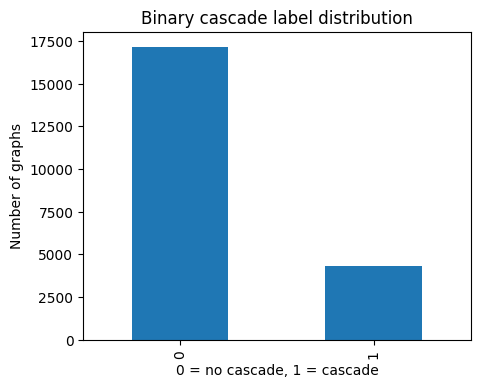

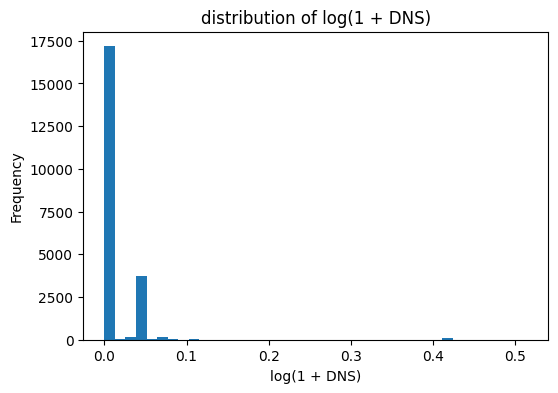

In [37]:
# Some plots for exploring data better

plt.figure(figsize = (5, 4))  # Creating a figure of size (5, 4)
pd.Series(class_labels).value_counts().sort_index().plot(kind = "bar")  # Counting how many graphs belong to each  binary class and plotting the result as a bar chart
plt.title("Binary cascade label distribution")
plt.xlabel("0 = no cascade, 1 = cascade")
plt.ylabel("Number of graphs")
plt.show()

plt.figure(figsize = (6, 4))  # Creating a figure of size (5, 4)
# Plotting the distributin of DNS values after applying log(1 + DNS) -> np.log1p(x) -> used instead of log(x) because it safely handles zero values
plt.hist(np.log1p(dns_values), bins = 40)
plt.title("distribution of log(1 + DNS)")
plt.xlabel("log(1 + DNS)")
plt.ylabel("Frequency")
plt.show()

## 9. Train / Validation / Test split and Normalization

I splitted the data into 70% train, 15 % validation and 15% test. I normalized node and edge features using only the training set, to avoid data leakage.

In [38]:
# Splitting data

indices = np.arange(len(graphs))  # Creating an array of indices from 0 to number_of_graphs - 1

# Frist split: 70% of the data goes to training, 30% is temporarily kept for validation and test. stratify = class_labels -> keeps the same class distribution in both parts
train_idx, temp_idx = train_test_split(indices, test_size = 0.30, random_state = SEED, stratify = class_labels)
# Second split: splitting the temporary 30% to validation and test -> 15% validation, 15% test. stratify = class_labels[temp_idx] -> keeps class balance in val and test sets
val_idx, test_idx = train_test_split(temp_idx, test_size = 0.50, random_state = SEED, stratify = class_labels[temp_idx])

# Using the selected indices to create the actual graph dataset
train_graphs = [graphs[i] for i in train_idx]
val_graphs = [graphs[i] for i in val_idx]
test_graphs = [graphs[i] for i in test_idx]

print("Train / val / test:", len(train_graphs), len(val_graphs), len(test_graphs))  # Prining the number of graphs in each split

Train / val / test: 15050 3225 3225


In [39]:
# Normalizing features

# This function computes mean and standard deviation for node features and edge features -> only on the training set
def compute_feature_stats(data_list):
    # Concatenating node features from all training graphs
    all_x = torch.cat([g.x for g in data_list], dim = 0)
    # Concatenating edge features from all training graphs
    all_e = torch.cat([g.edge_attr for g in data_list], dim = 0)

    # Edge attributes: first columns = continous electrical features
    # last column = binary initial_falied_flag, so I dont normalize it
    continuous_e = all_e[:, :-1]

    # Returning mean and std for node and continuous edge features
    return {"x_mean": all_x.mean(dim = 0, keepdim = True),
            "x_std": all_x.std(dim = 0, keepdim = True).clamp(min = 1e-6),  # .clamp(min = 1e-6) -> If any value is smaller than 1e-6 (0.000001), replace it with 1e-6
            "e_mean": continuous_e.mean(dim = 0, keepdim = True),
            "e_std": continuous_e.std(dim = 0, keepdim = True).clamp(min = 1e-6),}


# This function applies normalization to a list of graphs. Node features are fully normalized, but edge features are normalized onoly for the continuous columns
# The binary edge status feature is kept unchanged
def apply_normalization(data_list, stats):
    normalized = []

    for g in data_list:
        g = g.clone()  # Cloning the graph to avoid modifying the original object directly

        # Normalizing node features using training set mean & std
        g.x = (g.x - stats["x_mean"]) / stats["x_std"]

        # Splitting edfe features to continuous and binary status features
        edge_continuous = g.edge_attr[:, :-1]
        edge_status = g.edge_attr[:, -1:].clone()

        # Normalizing only continuos features
        edge_continuous = (edge_continuous - stats["e_mean"]) / stats["e_std"]

        # Recombining normalized continous features with unchanged binary feature
        g.edge_attr = torch.cat([edge_continuous, edge_status], dim = 1)

        normalized.append(g)  # Storing normalized graph

    return normalized

stats = compute_feature_stats(train_graphs)  # Computing normalization statistics only from training samples

# Applting them to train, validation, and test sets
train_graphs = apply_normalization(train_graphs, stats)
val_graphs = apply_normalization(val_graphs, stats)
test_graphs = apply_normalization(test_graphs, stats)

# Updating edge and node feature dimensions after normalization
NODE_DIM = train_graphs[0].x.shape[1]
EDGE_DIM = train_graphs[0].edge_attr.shape[1]

print("NODE_DIM:", NODE_DIM)
print("EDGE_DIM:", EDGE_DIM)
print("Example edge_attr:", train_graphs[0].edge_attr[:5])  # Printing a small example of normalized edge attributes

# Creating DataLoaders
BATCH_SIZE = 32  # The number of graphs processed together in each batch

# DataLoader for training data. shuffle = True -> randomizes batches during training
train_loader = DataLoader(train_graphs, batch_size = BATCH_SIZE, shuffle = True)
# DataLoader for validation data. shuffle = False -> keeps the order fixed during validation
val_loader = DataLoader(val_graphs, batch_size = BATCH_SIZE, shuffle = False)
# DataLoader for test data. shuffle = False -> keeps the order fixed during final testing
test_loader = DataLoader(test_graphs, batch_size = BATCH_SIZE, shuffle = False)

print("DataLoaders ready.")

NODE_DIM: 3
EDGE_DIM: 5
Example edge_attr: tensor([[ 0.7868, -0.7643, -1.2122, -1.4564,  0.0000],
        [ 0.2851,  0.3484,  2.8822, -1.4564,  0.0000],
        [ 0.7452, -0.4242,  0.2529, -1.4564,  0.0000],
        [ 0.6421,  0.2527,  1.1287, -1.4564,  0.0000],
        [ 0.7457, -0.5128,  2.4838, -1.4564,  0.0000]])
DataLoaders ready.


## 10. Model Definitions

All models use two heads:
1. Classification head for cascade/no cascade
2. Regression head for DNS severity

For DNS -> train on log(1 + DNS) to reduce skewness

In [40]:
# General utilities

# This function pools node embeddings. x contains the embeddings. Batch tells PyTorch geometric which graph each node belongs to. Pooling decides how node embeddings are aggregated
def pool_nodes(x, batch, pooling = "mean"):
    if pooling == "mean":   # Average all node embeddings in each graph
        return global_mean_pool(x, batch)
    if pooling == "max":  # Take the maximum value across nodes for each graph
        return global_max_pool(x, batch)
    if pooling == "sum":  # Sum all node embeddings in each graph
        return global_add_pool(x, batch)
    if pooling == "meanmax":  # Concatenate min pooling and max pooling -> this gives a richer graph representation
        return torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim = 1)
    raise ValueError(f"Unknown pooling: {pooling}")  # Stopp the code if an unknown poooling method is provided


# This function returns the output dimension after  pooling. Mean, max, and sum keep the same hidden dimension. Meanmax doubles it cuz mean and max are concatenated
def get_pool_dim(hidden_dim, pooling):
    return hidden_dim * 2 if pooling == "meanmax" else hidden_dim


# Counting the number of trainable parameters in a model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# This function estimates the model size in megabytes. Each parameter is assumed to use 4 bytes which corresponds to float32 precision
def model_size_mb(model):
    return count_parameters(model) * 4 / (1024 ** 2)


# This function assigns each edge to the graph it belongs to inside a mini batch. Each edge is assigned based on its source node.
def get_edge_batch(batch):
    # batch.batch -> which graph each node belongs to
    # batch.edge_index[0] -> contains the source node of each edge
    return batch.batch[batch.edge_index[0]]

In [41]:
# FCNN baseline

# Simple baseline model that doesnt use graph cpnvolutions. The graph is summarized using mean and max pooling of node and edge features, then processed by a standard feed forward neural network
# Outputs: 1.Binary classification prediction (cascade/no cascade)   2. Regression prediction(DNV value)
class FCNNBaseline(nn.Module):
    def __init__(self, node_dim = 3, edge_dim = 4, hidden_dim = 64, dropout = 0.2):
        super().__init__()

        # graph representation consists of: node_mean + node_max + edge_mean + edge_max
        # node_mean & node_max -> node_dim     ,      edge_mean & edge_max -> edge_dim
        input_dim = node_dim * 2 + edge_dim * 2

        # Feed forward neural network
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim),  # First hidden layer
                                 nn.ReLU(),
                                 nn.Dropout(dropout),
                                 nn.Linear(hidden_dim, hidden_dim),  # Second hidden layer
                                 nn.ReLU(),
                                 nn.Dropout(dropout), )

        self.class_head = nn.Linear(hidden_dim, 1)  # Classification head, output -> a single logit for binary classification
        self.reg_head = nn.Linear(hidden_dim, 1)  # Regression head, output -> a single continuous value


    def forward(self, batch):
        edge_batch = get_edge_batch(batch)  # Determining which graph each edge belongs to

        # Pooling node features
        node_mean = global_mean_pool(batch.x, batch.batch)  # Average node features within each graph
        node_max = global_max_pool(batch.x, batch.batch)  # Maximum node features within each graph
        # Pooling edge features
        edge_mean = global_mean_pool(batch.edge_attr, edge_batch)  # Average edge features within each graph
        edge_max = global_max_pool(batch.edge_attr, edge_batch)  # Maximum edge features within each graph

        # Building graph level feature vector
        graph_feat = torch.cat([node_mean, node_max, edge_mean, edge_max], dim = 1)
        h = self.net(graph_feat)  # Passing graph features through the FCNN

        class_logit = self.class_head(h).squeeze(-1)  # Binary classification output
        reg_log = self.reg_head(h).squeeze(-1)  # Regression output
        return class_logit, reg_log

A normal GCNConv uses graph topology and node features, but it doesnt use multidimensional edge features. To make the comparison fairer against GAT, I changed GCNConv to GINEConv (Graph Isomorphism Network with Edge Features). It is still a non attention message passing graph neural network, but it can include edge_attr.

In [42]:
# Edge awaree GINE baseline (former GCN) -> GNN baseline using GINEConv layers


# Graph NN for multitask learning. It uses GINEConv layers to incorporate both node features & edge features
# Outputs: 1. Binary classification prediction   2. DNS regression prediction
class GCNMultiTask(nn.Module):

    def __init__(self, node_dim = NODE_DIM, edge_dim = EDGE_DIM, hidden_dim = 64, num_layers = 2, dropout = 0.2, pooling = "mean", mlp_hidden = 64):

        super().__init__()

        # Storing hyperparameters
        self.dropout = dropout
        self.pooling = pooling

        self.convs = nn.ModuleList()  # List of graph convolution layers

        in_dim = node_dim  # Initial node feature dimension

        # Building GINE convolution stack
        for _ in range(num_layers):
            # Small mlp used internally by GINEConv
            mlp = nn.Sequential(nn.Linear(in_dim, hidden_dim),
                                nn.ReLU(),
                                nn.Linear(hidden_dim, hidden_dim),)

            self.convs.append(GINEConv(nn = mlp, edge_dim = edge_dim, train_eps = True, ))  # Egde aware graph convolution layer

            in_dim = hidden_dim  # Output dimension becomes input dimension for the next GNN layer

        pooled_dim = get_pool_dim(hidden_dim, pooling)  # Graph embedding size after pooling

        # Graph level mlp
        self.mlp = nn.Sequential(nn.Linear(pooled_dim, mlp_hidden),
                                nn.ReLU(),
                                nn.Dropout(dropout), )

        self.class_head = nn.Linear(mlp_hidden, 1)  # Classification head
        self.reg_head = nn.Linear(mlp_hidden, 1)  # Regression head


    def forward(self, batch):
        x = batch.x  # Initial node features

        # Message passing
        for conv in self.convs:
            # Updating node embeddings using: neighboring nodes, edge features
            x = conv(x, batch.edge_index, batch.edge_attr)
            x = F.relu(x)  # Activation function
            x = F.dropout(x, p = self.dropout, training = self.training)  # Dropout for regularization

        # Graph pooling
        graph_emb = pool_nodes(x, batch.batch, self.pooling)  # Converting node embeddings to graph embeddings
        h = self.mlp(graph_emb)  # Graph level representation

        class_logit = self.class_head(h).squeeze(-1)  # Binary classification prediction
        reg_log = self.reg_head(h).squeeze(-1)  # DNS regression prediction

        return class_logit, reg_log

In [43]:
# GAT model -> edge aware multitask


# Graph attention model for multitask learning. It uses GATConv layers with edge features.
# Outputs: 1. Binary classification prediction   2. DNS regression prediction
# Optional: Attention weights for interpretability
class GATMultiTask(nn.Module):
    def __init__(self, node_dim = NODE_DIM, edge_dim = EDGE_DIM, hidden_dim = 64, num_layers = 2, heads = 2, dropout = 0.2, pooling = "mean", mlp_hidden = 64, ):

        super().__init__()

        # Storing model hyperparameters
        self.node_dim = node_dim
        self.edge_dim = edge_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.heads = heads
        self.dropout = dropout
        self.pooling = pooling
        self.mlp_hidden = mlp_hidden

        self.convs = nn.ModuleList()  # List of GAT convolution layers

        in_dim = node_dim  # Initial node feature dimension is the node feature dimension

        # Building the GAT layers
        for _ in range(num_layers):
            self.convs.append(GATConv(in_channels = in_dim, out_channels = hidden_dim, heads = heads, concat = False, dropout = dropout, edge_dim = edge_dim, add_self_loops = False, ))

            in_dim = hidden_dim  # Output dimension becomes input dimension for the next layer


        pooled_dim = get_pool_dim(hidden_dim, pooling)  # Graph embedding size after pooling

        # Graph level mlp
        self.mlp = nn.Sequential(nn.Linear(pooled_dim, mlp_hidden),
                                 nn.ReLU(),
                                 nn.Dropout(dropout), )

        self.class_head = nn.Linear(mlp_hidden, 1)  # Binary classification head
        self.reg_head = nn.Linear(mlp_hidden, 1)  # DNS regression head



    def forward(self, batch, return_attention = False):
        x = batch.x  # Initial node features
        attention_outputs = []  # Storing attention weights if requested

        # Applying each GAT layer
        for conv in self.convs:
            if return_attention:
                # Return both updated node embeddings and attention weights
                x, att = conv(x, batch.edge_index, edge_attr = batch.edge_attr, return_attention_weights = True,)
                attention_outputs.append(att)

            else:
                # Standard forward pass without returning attention weights
                x = conv(x, batch.edge_index, edge_attr = batch.edge_attr, )

            x = F.elu(x)  # ELU activation is commonly used in GAT models   ELU(x)={x​             x>0
                          #                                                       {(e ** x)−1    x≤0​
            x = F.dropout(x, p = self.dropout, training = self.training)  # Dropout for regularization


        graph_emb = pool_nodes(x, batch.batch, self.pooling)  # Converting node embeddings to graph level embeddings
        h = self.mlp(graph_emb)  # Graph level representation

        class_logit = self.class_head(h).squeeze(-1)  # Binary classification prediction
        reg_log = self.reg_head(h).squeeze(-1)  # DNS regression prediction

        # Optionally returning attention weights for explainability
        if return_attention:
            return class_logit, reg_log, attention_outputs

        return class_logit, reg_log

## 11. Training and evaluation functions

The multitask loss is: classification_loss + BETA_REG * regression_loss

The regression loss uses long DNS

In [44]:
# Multitask training and evaluation utilities

# The weight used to balance the regression loss against the classification loss.
BETA_REG = 0.3


# This function computes the total multitask loss. The classification task uses binary cross entropy. The regression task uses mean squared error on log tranformes DNS.
def multitask_loss(class_logit, reg_log, batch, beta = BETA_REG):
    y_class = batch.y_class.float().view(-1)  # True binary lables, converted to float cuz BCE loss expects float tragets
    # view(-1) -> Converts the labels from shape [batch_size, 1] to shape [batch_size] so they match the model outputs and can be used in the loss function
    y_reg_log = torch.log1p(batch.y_reg.float().view(-1))  # True DNS regression labels. log1p -> log(1 + DNS), useful because DNS values can be very skewed

    loss_class = F.binary_cross_entropy_with_logits(class_logit, y_class)  # classification loss. This function expects raw logits, not sigmoid probabilities
    loss_reg = F.mse_loss(reg_log, y_reg_log)  # Regression loss between predicted log DNS and true log DNS
    return loss_class + beta * loss_reg  # Total multitask loss



# This function trains the model for one full epoch.
def train_one_epoch(model, loader, optimizer):
    model.train()   # Putting the model in training mode -> activating dropout and other training specific behaviors
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)  # Moving batch to CPU or GPU
        optimizer.zero_grad()  # Clearing old gradients
        class_logit, reg_log = model(batch)  # Forward pass
        loss = multitask_loss(class_logit, reg_log, batch)  # Computing multitask loss using the function above
        loss.backward()  # Backpropagation
        optimizer.step()  # Updating model parameters
        total_loss += loss.item() * batch.num_graphs  # Accumulating loos weighted by the number of graphs in the batch

    return total_loss / len(loader.dataset)  # Returning average loss per graph



@torch.no_grad()
# Running the model on a Dataloader without training -> used for validation and testing -> returns predictions, probabilities, true labels, DNS prediction, true DNS values, and average loss
def predict_loader(model, loader, threshold = 0.5):
    model.eval()  # putting the model on evaluation mode -> disables dropout
    # Dictionary used to  store all the predictions and true values
    outputs = {"probs": [], "pred_class": [], "true_class": [], "pred_dns": [], "true_dns": []}

    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        class_logit, reg_log = model(batch)  # Forward pass
        # Computing validation/test loss
        loss = multitask_loss(class_logit, reg_log, batch)
        total_loss += loss.item() * batch.num_graphs

        prob = torch.sigmoid(class_logit)  # Converting raw classification logits into probabilities between 0 and 1

        # Converting probabilities into binary predictions using a threshold
        # This part was changed after the first phase: the threshold is now configurable instead of fixed at 0.5
        pred_class = (prob >= threshold).long()

        # Converting predicted log DNS back to normal DNS scale.  expm1 -> the inverse og log1p
        # clamp(min = 0) -> prevents negative DNS predictions
        pred_dns = torch.expm1(reg_log).clamp(min = 0)

        # Storing values on CPU for later metric calculation
        outputs["probs"].append(prob.cpu())
        outputs["pred_class"].append(pred_class.cpu())
        outputs["true_class"].append(batch.y_class.view(-1).cpu())
        outputs["pred_dns"].append(pred_dns.cpu())
        outputs["true_dns"].append(batch.y_reg.view(-1).cpu())

    # Concatenating all batches into single NumPy arrays
    for k in outputs:
        outputs[k] = torch.cat(outputs[k]).numpy()

    outputs["loss"] = total_loss / len(loader.dataset)  # Storing average loss

    return outputs


# This function computes classification and regression metrics from model predictions
def evaluate_predictions(pred):
    # Classification values
    y_true = pred["true_class"]
    y_pred = pred["pred_class"]
    y_prob = pred["probs"]
    # Regression values
    true_dns = pred["true_dns"]
    pred_dns = pred["pred_dns"]

    # AUROC can fail if only one class is present -> in that case return NaN instead of crashing
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
      auroc = np.nan

    return {"loss": pred["loss"],  # Total multitask loss
            # Classification metrics
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division = 0),
            "recall": recall_score(y_true, y_pred, zero_division = 0),
            "f1": f1_score(y_true, y_pred, zero_division = 0),
            "auroc": auroc,
            # Regression metrics for DNS prediction
            "mae_dns": mean_absolute_error(true_dns, pred_dns),
            "rmse_dns": mean_squared_error(true_dns, pred_dns) ** 0.5,
            "r2_dns": r2_score(true_dns, pred_dns),}


# Full training loop with validation and early stopping. The model is trained on the training set, after each epoch, its evaluated on the validation set.
# The best model is selected based on validation loss
def train_model(model, train_loader, val_loader, epochs = 50, lr = 1e-3, weight_decay = 1e-4, patience = 10, verbose = True):
    model = model.to(device)  # Moving model to cpu or GPU
    # AdamW optimizer with weight decay regularization
    optimizer = torch.optim.AdamW(model.parameters(), lr = lr, weight_decay = weight_decay)

    best_state = None  # To stor the best model weights
    best_val_loss = float("inf")  # Best validation loss seen so far
    patience_counter = 0  # To count how many epoch have passed without improvement
    history = []  # To store training history

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)  # Training for 1 epoch using the function above
        val_pred = predict_loader(model, val_loader)  # Predicting on evaluation set using the function above
        val_metrics = evaluate_predictions(val_pred)  # Computing validation metrics using the function above

        # Saving epoch results
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_metrics["loss"], "val_f1": val_metrics["f1"], "val_auroc": val_metrics["auroc"],})


        # Printing progress every 5 epochs and on the first epoch
        if verbose and (epoch == 1 or epoch % 5 == 0):
          print(f"Epoch {epoch:03d} | train_loss = {train_loss:.4f} | val_loss = {val_metrics['loss']:.4f} | val_f1 = {val_metrics['f1']:.4f}")


        # If validation loss improves, save the model state
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            # Saving model weights on CPU -> to be used later in case of overfitting
            best_state ={k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            # v.detach() -> to remove the tensor from PyTorch's computation graph -> no need of gradients for saved weights
            # clone() -> Creates a compeletly independant copy
            patience_counter = 0  # Resetting patience counter
        else:
            patience_counter += 1  # No improvments

        # Stop the training if validation loss didnt mimprove for too long
        if patience_counter >= patience:
            if verbose:
                print("Early stopping.")
            break
    # Restoring the best model weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)  # Returning trained model and the training history as ad Daataframe



# This function estimates average inference latency per graph in miliseconds. A few warm up batches are run first to stabilize the performance, then timing is measured
# over a fixed no. of batches and averaged
def measure_latency_ms(model, loader, warmup_batches = 2, measured_batches = 10):

    model.eval()
    model = model.to(device)
    times = []  # To store measured batch inference times in miliseconds

    for i, batch in enumerate(loader):
        batch = batch.to(device)

        # Warm up phase -> running a few forward passes without measuring time
        if i < warmup_batches:
            _ = model(batch)
            continue

        # Synchronizing GPU before timing -> this makes timing more accurate on cuda
        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()  # Stariting the timer

        _ = model(batch)  # Forward pass only

         # Synchronizing GPU after timing
        if device.type == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()  # Ending timer

        times.append((end - start) * 1000)  # Storing batch inference time in miliseconds
        # Stopping after collecting the requested no. of measurements
        if len(times) >= measured_batches:
            break

    return float(np.mean(times)) if len(times) > 0 else np.nan  # Returning average latency across measured batches



# Evaluating a model and retuning both metrics and raw predictions. It also adds extra info: model name, threshold, no. of parameters, estimated model size, latency
def evaluate_model(name, model, loader, threshold = 0.5):
    pred = predict_loader(model, loader, threshold = threshold)  # Getting the predictions (function above)
    metrics = evaluate_predictions(pred)  # Computing metrics (function above)

    # Adding model metadata
    metrics["model"] = name
    metrics["threshold"] = threshold
    metrics["parameters"] = count_parameters(model)
    metrics["model_size_mb"] = model_size_mb(model)
    metrics["latency_ms"] = measure_latency_ms(model, loader)

    return metrics, pred

## 12. Training baselines and manual GAT

In [45]:
# Training FCNN, edge aware GINE, and manual GAT

baseline_results = []  # To store the final test metrics of all baseline models

# No. of training epochs
EPOCHS_BASE = 20 if FAST_RUN else 80

# 1. FCNN baseline
print("\n" + "=" * 70)
print("Training FCNN baseline")
print("=" * 70)

# Creating the FCNN baseline model -> it doesnt use graph message passing -> only uses pooled node and edge statistics
fcnn = FCNNBaseline(node_dim = NODE_DIM, edge_dim = EDGE_DIM, hidden_dim = 64, dropout = 0.2, )

# Train the FCNN model using the train and validation loaders. Early stopping patience is set to 8 epochs
fcnn, hist_fcnn = train_model(fcnn, train_loader, val_loader, epochs = EPOCHS_BASE, lr = 1e-3, patience = 8, )

fcnn_metrics, fcnn_pred = evaluate_model("FCNN", fcnn, test_loader, )  # Evaluating the trained FCNN on the test set

baseline_results.append(fcnn_metrics)  # Storing metrics for later comparison

print("FCNN test metrics:")
display(pd.DataFrame([fcnn_metrics]))   # Displaying FCNN test metrics as a 1 row table


# 2. Edge aware GINE basekine
print("\n" + "=" * 70)
print("Training edge aware GINE baseline")
print("=" * 70)

# Creaating the edge awate GINE model. the variable is named gcn (because of the first phase), but the model uses GINEConv
gcn = GCNMultiTask(node_dim = NODE_DIM, edge_dim = EDGE_DIM, hidden_dim = 64, num_layers = 2, dropout = 0.2, pooling = "mean", mlp_hidden = 64, )

gcn, hist_gcn = train_model(gcn, train_loader, val_loader, epochs = EPOCHS_BASE, lr = 1e-3, patience = 8, )  # Training the GINE model

gcn_metrics, gcn_pred = evaluate_model("Edge aware GINE", gcn, test_loader, )  # Evaluating the trained GINE model on the test set

baseline_results.append(gcn_metrics)  # Storing metrics for later comparison

print("Edge aware GINE test metrics:")
display(pd.DataFrame([gcn_metrics]))  # Displaying GINE test metrics as a 1 row table


# 3. Manual GAT
print("\n" + "=" * 70)
print("Training manual GAT")
print("=" * 70)

# Configuration dictionary for the manually selected GAT architecture
manual_gat_cfg = {"hidden_dim": 64, "num_layers": 2, "heads": 2, "dropout": 0.2, "pooling": "mean", "mlp_hidden": 64, "lr": 1e-3, }

# Creating the manually configured GAT model
manual_gat = GATMultiTask(node_dim = NODE_DIM, edge_dim = EDGE_DIM, hidden_dim = manual_gat_cfg["hidden_dim"], num_layers = manual_gat_cfg["num_layers"],
                          heads = manual_gat_cfg["heads"], dropout = manual_gat_cfg["dropout"], pooling = manual_gat_cfg["pooling"], mlp_hidden = manual_gat_cfg["mlp_hidden"], )

manual_gat, hist_gat = train_model(manual_gat, train_loader, val_loader, epochs = EPOCHS_BASE, lr = manual_gat_cfg["lr"], patience = 8, )  # Training the GAT model

manual_gat_metrics, manual_gat_pred = evaluate_model("Manual GAT", manual_gat, test_loader, )  # Evaluating the trained GAT model on the test set

baseline_results.append(manual_gat_metrics)   # Storing metrics for later comparison

print("Manual GAT test metrics:")
display(pd.DataFrame([manual_gat_metrics]))  # Displaying GAT test metrics as a 1 row table


# Baseline comparison table
baseline_df = pd.DataFrame(baseline_results)  # Converting all collected metrics into a dataframe

print("\nBaseline comparison:")
# Displaying the selected metrics and sort models by f1 score
display(baseline_df[["model", "accuracy", "precision", "recall", "f1", "auroc", "mae_dns", "rmse_dns", "r2_dns", "parameters", "model_size_mb", "latency_ms",
                     "loss",]].sort_values("f1", ascending = False))


Training FCNN baseline
Epoch 001 | train_loss = 0.4294 | val_loss = 0.3572 | val_f1 = 0.5481
Epoch 005 | train_loss = 0.3015 | val_loss = 0.3034 | val_f1 = 0.5922
Epoch 010 | train_loss = 0.2888 | val_loss = 0.2784 | val_f1 = 0.6794
Epoch 015 | train_loss = 0.2741 | val_loss = 0.2695 | val_f1 = 0.6655
Epoch 020 | train_loss = 0.2657 | val_loss = 0.2633 | val_f1 = 0.6931
Epoch 025 | train_loss = 0.2634 | val_loss = 0.2555 | val_f1 = 0.6847
Epoch 030 | train_loss = 0.2608 | val_loss = 0.2565 | val_f1 = 0.6521
Epoch 035 | train_loss = 0.2538 | val_loss = 0.2515 | val_f1 = 0.7039
Epoch 040 | train_loss = 0.2495 | val_loss = 0.2450 | val_f1 = 0.6952
Epoch 045 | train_loss = 0.2426 | val_loss = 0.2390 | val_f1 = 0.7168
Epoch 050 | train_loss = 0.2371 | val_loss = 0.2416 | val_f1 = 0.7077
Epoch 055 | train_loss = 0.2316 | val_loss = 0.2314 | val_f1 = 0.7406
Epoch 060 | train_loss = 0.2307 | val_loss = 0.2340 | val_f1 = 0.6957
Epoch 065 | train_loss = 0.2211 | val_loss = 0.2119 | val_f1 = 0.7

,loss,accuracy,precision,recall,f1,auroc,mae_dns,rmse_dns,r2_dns,model,threshold,parameters,model_size_mb,latency_ms
0,0.189392,0.91938,0.853261,0.724615,0.783694,0.96501,0.013187,0.043705,0.118402,FCNN,0.5,5378,0.020515,1.159164



Training edge aware GINE baseline
Epoch 001 | train_loss = 0.3949 | val_loss = 0.3100 | val_f1 = 0.6383
Epoch 005 | train_loss = 0.2596 | val_loss = 0.2194 | val_f1 = 0.7778
Epoch 010 | train_loss = 0.1387 | val_loss = 0.1191 | val_f1 = 0.9057
Epoch 015 | train_loss = 0.1021 | val_loss = 0.0867 | val_f1 = 0.9279
Epoch 020 | train_loss = 0.0728 | val_loss = 0.0599 | val_f1 = 0.9461
Epoch 025 | train_loss = 0.0622 | val_loss = 0.0572 | val_f1 = 0.9392
Epoch 030 | train_loss = 0.0585 | val_loss = 0.0490 | val_f1 = 0.9476
Epoch 035 | train_loss = 0.0568 | val_loss = 0.0425 | val_f1 = 0.9609
Epoch 040 | train_loss = 0.0531 | val_loss = 0.0330 | val_f1 = 0.9688
Epoch 045 | train_loss = 0.0485 | val_loss = 0.0356 | val_f1 = 0.9684
Epoch 050 | train_loss = 0.0469 | val_loss = 0.0421 | val_f1 = 0.9509
Early stopping.
Edge aware GINE test metrics:


,loss,accuracy,precision,recall,f1,auroc,mae_dns,rmse_dns,r2_dns,model,threshold,parameters,model_size_mb,latency_ms
0,0.030932,0.988217,0.984177,0.956923,0.970359,0.998767,0.009541,0.041335,0.211433,Edge aware GINE,0.5,17430,0.06649,2.689218



Training manual GAT
Epoch 001 | train_loss = 0.4205 | val_loss = 0.3432 | val_f1 = 0.5573
Epoch 005 | train_loss = 0.3437 | val_loss = 0.3046 | val_f1 = 0.5610
Epoch 010 | train_loss = 0.3204 | val_loss = 0.2959 | val_f1 = 0.6359
Epoch 015 | train_loss = 0.3105 | val_loss = 0.2768 | val_f1 = 0.6737
Epoch 020 | train_loss = 0.2874 | val_loss = 0.2619 | val_f1 = 0.6367
Epoch 025 | train_loss = 0.2773 | val_loss = 0.2451 | val_f1 = 0.6770
Epoch 030 | train_loss = 0.2761 | val_loss = 0.2606 | val_f1 = 0.6310
Epoch 035 | train_loss = 0.2678 | val_loss = 0.2343 | val_f1 = 0.7211
Epoch 040 | train_loss = 0.2632 | val_loss = 0.2300 | val_f1 = 0.7725
Epoch 045 | train_loss = 0.2648 | val_loss = 0.2207 | val_f1 = 0.7525
Epoch 050 | train_loss = 0.2643 | val_loss = 0.2198 | val_f1 = 0.7173
Epoch 055 | train_loss = 0.2569 | val_loss = 0.2065 | val_f1 = 0.7824
Epoch 060 | train_loss = 0.2589 | val_loss = 0.2117 | val_f1 = 0.7522
Early stopping.
Manual GAT test metrics:


,loss,accuracy,precision,recall,f1,auroc,mae_dns,rmse_dns,r2_dns,model,threshold,parameters,model_size_mb,latency_ms
0,0.213885,0.915039,0.805195,0.763077,0.78357,0.956488,0.012095,0.044931,0.068247,Manual GAT,0.5,15042,0.057381,7.448483



Baseline comparison:


,model,accuracy,precision,recall,f1,auroc,mae_dns,rmse_dns,r2_dns,parameters,model_size_mb,latency_ms,loss
1,Edge aware GINE,0.988217,0.984177,0.956923,0.970359,0.998767,0.009541,0.041335,0.211433,17430,0.066490,2.689218,0.030932
0,FCNN,0.919380,0.853261,0.724615,0.783694,0.965010,0.013187,0.043705,0.118402,5378,0.020515,1.159164,0.189392
2,Manual GAT,0.915039,0.805195,0.763077,0.783570,0.956488,0.012095,0.044931,0.068247,15042,0.057381,7.448483,0.213885


## 13. Efficiency measurement

I measure parameter counts, approximate model size, and inference latency

In [46]:
# Printing efficency info for each trained model
for model_name, model in [("FCNN", fcnn), ("GCN", gcn), ("Manual GAT", manual_gat)]:
    print(model_name, "| params:", count_parameters(model),  # No. of trainable parameters
                      "| size MB:", round(model_size_mb(model), 4),   # Estimated model size in megabytes
                      "| latency ms:", round(measure_latency_ms(model, test_loader), 4))   # Average inference latency

FCNN | params: 5378 | size MB: 0.0205 | latency ms: 1.0274
GCN | params: 17430 | size MB: 0.0665 | latency ms: 3.3233
Manual GAT | params: 15042 | size MB: 0.0574 | latency ms: 8.2613


## 14. Neural Architecture Search

I use a small constrained random search over GAT architectures.

The objectives:1. rewarding f1  2. adding smaller reward dor AUROC  3. penalizing the model with many parameters  4. penalizing slower models

score = (f1 + 0.2 * auroc - 1e-6 * params - 0.002 * latency)


In [47]:
# NAS search for GAT using f1/AUROC based objective. The goal is to automatically test different GAT configurations and select the best one based on validation performance

import copy

# Keeping a compact search space. This is NOT the expanded search space
# Each key is a hyperparameter and each value is a list of possible choices
search_space = {"hidden_dim": [32, 64], "num_layers": [2, 3], "heads": [2, 4], "dropout": [0.1, 0.2, 0.3], "pooling": ["mean", "max"],
                "mlp_hidden": [32, 64], "lr": [5e-4, 1e-3], }

# The no. of NAS trials and epochs. FAST_RUN uses fewer trials/epochs for quicker testing
NAS_TRIALS = 4 if FAST_RUN else 12
NAS_EPOCHS = 10 if FAST_RUN else 40


# This function randomly samples one configuration from the search space
def sample_nas_config(search_space):
    return {key: random.choice(values) for key, values in search_space.items()}


# In this function higher score is better. The score rewards validation f1 and AUROC, while applying small penalties for model size and latency
def nas_score_from_metrics(model, val_metrics, val_loader):

    params = count_parameters(model)  # Counting trainable model parameters
    latency = measure_latency_ms(model, val_loader)  # Estimating inference latency

    # Extracting validation f1 and AUROC
    f1 = val_metrics["f1"]
    auroc = val_metrics["auroc"]

    # If AUROC is undefined replace it with 0
    if np.isnan(auroc):
        auroc = 0.0

    # NAS objective: 1. rewarding f1  2. adding smaller reward dor AUROC  3. penalizing the model with many parameters  4. penalizing slower models
    score = (f1 + 0.2 * auroc - 1e-6 * params - 0.002 * latency)

    return score, params, latency


best_score = -float("inf")   # To store best nas score found so far
best_nas_config = None  # To store best sampled configuration found so far
best_nas_model = None  # To store best trained NAS model found so far
nas_results = []  # To stor all trial results

# NAS loop
for trial in range(1, NAS_TRIALS + 1):
    print("\n" + "=" * 70)
    print(f"NAS trial {trial}/{NAS_TRIALS}")
    print("=" * 70)

    cfg = sample_nas_config(search_space)  # Randomly sampling one NAS configuration
    print("Config:", cfg)

    # Building a GAT model using the sampled configuration
    model = GATMultiTask(node_dim = NODE_DIM, edge_dim = EDGE_DIM, hidden_dim = cfg["hidden_dim"], num_layers = cfg["num_layers"],
                          heads = cfg["heads"], dropout = cfg["dropout"], pooling = cfg["pooling"], mlp_hidden = cfg["mlp_hidden"], )

    # Training the sampled GAT model
    model, hist = train_model(model, train_loader, val_loader, epochs = NAS_EPOCHS, lr = cfg["lr"], patience = 6, verbose = False, )

    # Prediciting on the validation set using threshold 0.5
    val_pred = predict_loader(model, val_loader, threshold = 0.5)
    val_metrics = evaluate_predictions(val_pred)  # Computing validation metrics

    # Computing NAs score, including performance, parameter and latency penalties
    score, params, latency = nas_score_from_metrics(model, val_metrics, val_loader, )

    # Storing all relevant info for this trial
    trial_result = {"trial": trial, "score": score, "val_loss": val_metrics["loss"], "val_f1": val_metrics["f1"], "val_precision": val_metrics["precision"],
                    "val_recall": val_metrics["recall"], "val_auroc": val_metrics["auroc"], "parameters": params, "latency_ms": latency, **cfg, }

    nas_results.append(trial_result)

    # Priniting trial summary
    print(f"score = {score:.4f} | "
          f"val_f1 = {val_metrics['f1']:.4f} | "
          f"val_recall = {val_metrics['recall']:.4f} | "
          f"val_auroc = {val_metrics['auroc']:.4f} | "
          f"params = {params} | "
          f"latency = {latency:.3f} ms")


    # If this trial is the best so far, save its score, config, and model
    if score > best_score:
        best_score = score
        best_nas_config = cfg.copy()
        # Deepcopy creates an independant copy of the trained model.
        # .cpu() -> moves the model to cpu to reduce GPU memory usage
        best_nas_model = copy.deepcopy(model).cpu()


# Converting NAS results into a DataFrame end sort from best to worst score
nas_results_df = pd.DataFrame(nas_results).sort_values("score", ascending = False, )

print("\nBest NAS configuration:")
print(best_nas_config)

# Displaying all NAS trials, sorted by score
display(nas_results_df)


# Evaluating best NAS-GAT on the test set at threshold 0.5 first. The final tuned threshold evaluation will be done later
nas_gat_metrics, nas_gat_pred = evaluate_model("NAS-GAT", best_nas_model, test_loader, threshold = 0.5, )

display(pd.DataFrame([nas_gat_metrics]))  # Displaying test metrics for the best NAS-GAT model


NAS trial 1/12
Config: {'hidden_dim': 32, 'num_layers': 3, 'heads': 2, 'dropout': 0.1, 'pooling': 'max', 'mlp_hidden': 64, 'lr': 0.001}
score = 0.9777 | val_f1 = 0.8119 | val_recall = 0.8400 | val_auroc = 0.9509 | params = 8162 | latency = 8.116 ms

NAS trial 2/12
Config: {'hidden_dim': 64, 'num_layers': 2, 'heads': 2, 'dropout': 0.3, 'pooling': 'max', 'mlp_hidden': 32, 'lr': 0.0005}
score = 0.7357 | val_f1 = 0.5897 | val_recall = 0.5969 | val_auroc = 0.8746 | params = 12898 | latency = 7.972 ms

NAS trial 3/12
Config: {'hidden_dim': 32, 'num_layers': 2, 'heads': 2, 'dropout': 0.3, 'pooling': 'max', 'mlp_hidden': 32, 'lr': 0.001}
score = 0.9316 | val_f1 = 0.7580 | val_recall = 0.8215 | val_auroc = 0.9455 | params = 4450 | latency = 5.526 ms

NAS trial 4/12
Config: {'hidden_dim': 64, 'num_layers': 3, 'heads': 4, 'dropout': 0.3, 'pooling': 'mean', 'mlp_hidden': 32, 'lr': 0.001}
score = 0.9242 | val_f1 = 0.8145 | val_recall = 0.7938 | val_auroc = 0.9643 | params = 42018 | latency = 20.58

,trial,score,val_loss,val_f1,val_precision,val_recall,val_auroc,parameters,latency_ms,hidden_dim,num_layers,heads,dropout,pooling,mlp_hidden,lr
9,10,1.075363,0.112427,0.912837,0.941176,0.886154,0.983444,13986,10.088106,32,3,4,0.1,mean,64,0.0010
10,11,0.999474,0.141877,0.875796,0.907591,0.846154,0.977276,42018,14.879608,64,3,4,0.1,mean,32,0.0005
7,8,0.990491,0.172454,0.847512,0.885906,0.812308,0.968293,12866,18.906927,32,3,4,0.1,mean,32,0.0005
0,1,0.977684,0.217842,0.811896,0.785612,0.840000,0.950908,8162,8.116014,32,3,2,0.1,max,64,0.0010
2,3,0.931577,0.257367,0.757984,0.703557,0.821538,0.945479,4450,5.526436,32,2,2,0.3,max,32,0.0010
3,4,0.924185,0.190474,0.814522,0.836305,0.793846,0.964296,42018,20.589176,64,3,4,0.3,mean,32,0.0010
4,5,0.919316,0.205704,0.781411,0.886719,0.698462,0.959751,25666,14.189817,64,2,4,0.2,mean,64,0.0005
11,12,0.868120,0.265782,0.709416,0.750859,0.672308,0.926086,12898,6.807388,64,2,2,0.3,mean,32,0.0005
5,6,0.796876,0.408319,0.647848,0.598435,0.706154,0.895769,12898,8.613770,64,2,2,0.3,max,32,0.0005
8,9,0.755398,0.293048,0.600372,0.758216,0.496923,0.914785,7042,10.444248,32,3,2,0.3,mean,32,0.0010


,loss,accuracy,precision,recall,f1,auroc,mae_dns,rmse_dns,r2_dns,model,threshold,parameters,model_size_mb,latency_ms
0,0.115662,0.965891,0.94702,0.88,0.912281,0.984099,0.017059,0.044024,0.105489,NAS-GAT,0.5,13986,0.053352,9.525529


## 15. Structured pruning / compact GAT


In [48]:
# This function estimates the importance of each attention head using parameter magnitudes. This is a simple structured pruning criterion: heads with
# largere learned weights are considered more important
def get_head_importance_from_gatconv(conv):

    heads = conv.heads  # No. of attention heads in this GAT layer
    out_channels = conv.out_channels  # No. of output channels produced by each head

    importance = torch.zeros(heads)  # Tensor that will store one importance score per head

    # No gradients needed cuz this is only an analysis step
    with torch.no_grad():
        for h in range(heads):  # Looping over each attention head

            # Selecting the rows of the weight matrices corresponding to this head
            start = h * out_channels
            end = (h + 1) * out_channels

            score = 0.0  # Initializizng the importance score of this head

            # Node projection weights
            if hasattr(conv, "lin") and conv.lin is not None:  # Linear layer weights
                score += conv.lin.weight[start:end, :].abs().sum().item()  # Adding the total magnitude of all node projection weights belonging to yhis head

            if hasattr(conv, "lin_src") and conv.lin_src is not None:  # Source node tranformation
                score += conv.lin_src.weight[start:end, :].abs().sum().item()

            if hasattr(conv, "lin_dst") and conv.lin_dst is not None:  # Destination node tranformation
                score += conv.lin_dst.weight[start:end, :].abs().sum().item()

            # Edge projection weights
            if hasattr(conv, "lin_edge") and conv.lin_edge is not None:  # Linear projection to edges
                score += conv.lin_edge.weight[start:end, :].abs().sum().item()

            # Attention parameters for source nodes
            if hasattr(conv, "att_src") and conv.att_src is not None:
                score += conv.att_src[:, h, :].abs().sum().item()

            # Attention parameters for destination nodes
            if hasattr(conv, "att_dst") and conv.att_dst is not None:
                score += conv.att_dst[:, h, :].abs().sum().item()

            # Attention parameters for edge attributes
            if hasattr(conv, "att_edge") and conv.att_edge is not None:
                score += conv.att_edge[:, h, :].abs().sum().item()

            # Fianl score: node projection weights + source projection weights + destination projection weights + edge projection weights + attention weights

            importance[h] = score  # Storing the final importance score for this head

    return importance


# This function selects the most important heads for each GAT layer
def select_heads_to_keep(model, keep_ratio = 0.50):

    original_heads = model.convs[0].heads  # No. of heads in the original NAS-GAT model

    # Head pruning is only possible when there is mode than one head
    if original_heads <= 1:
        raise ValueError("The NAS-GAT has only 1 attention head, so head pruning is impossible."
                         "Change the NAS search space and rerun NAS.")

    # No. of heads to keep after pruning
    keep_heads = max(1, int(round(original_heads * keep_ratio)))

    keep_indices_per_layer = []   # This will store the selected head indices for each layer

    # Selecting heads independently for each GAT layer
    for layer_id, conv in enumerate(model.convs):
        importance = get_head_importance_from_gatconv(conv)  # Computing importance score for each head
        keep_indices = torch.topk(importance, k = keep_heads).indices.sort().values  # Keeping the heads with the highest importance scores
        keep_indices_per_layer.append(keep_indices)

        print(f"Layer {layer_id}")
        print("Head importance:", importance.numpy())
        print("Keeping heads:", keep_indices.numpy())

    return keep_indices_per_layer, keep_heads


# This function copies selected attention heads from old GATConv to new GATConv
def copy_selected_heads(old_conv, new_conv, keep_indices):

    old_heads = old_conv.heads  # No. of heads in the original layer
    out_channels = old_conv.out_channels  # No. of output channels per head

    row_indices = []  # To store row indices corresponding to the selected heads

    for h in keep_indices.tolist():
        start = h * out_channels
        end = (h + 1) * out_channels
        row_indices.extend(list(range(start, end)))

    row_indices = torch.tensor(row_indices, dtype = torch.long)

    # Copyning weights without tracking gradients
    with torch.no_grad():

        # Node projection weights
        if hasattr(old_conv, "lin") and old_conv.lin is not None:
            new_conv.lin.weight.copy_(old_conv.lin.weight[row_indices, :])

        if hasattr(old_conv, "lin_src") and old_conv.lin_src is not None:
            new_conv.lin_src.weight.copy_(old_conv.lin_src.weight[row_indices, :])

        if hasattr(old_conv, "lin_dst") and old_conv.lin_dst is not None:
            new_conv.lin_dst.weight.copy_(old_conv.lin_dst.weight[row_indices, :])

        # Edge projection weights
        if hasattr(old_conv, "lin_edge") and old_conv.lin_edge is not None:
            new_conv.lin_edge.weight.copy_(old_conv.lin_edge.weight[row_indices, :])

        # Attention vectors for source nodes
        if hasattr(old_conv, "att_src") and old_conv.att_src is not None:
            new_conv.att_src.copy_(old_conv.att_src[:, keep_indices, :])

        # Attention vectors for destination nodes
        if hasattr(old_conv, "att_dst") and old_conv.att_dst is not None:
            new_conv.att_dst.copy_(old_conv.att_dst[:, keep_indices, :])

        # Attention vectors for edge attributes
        if hasattr(old_conv, "att_edge") and old_conv.att_edge is not None:
            new_conv.att_edge.copy_(old_conv.att_edge[:, keep_indices, :])

        # Bias is not head specific when concat = False,  so it can be copied directly
        if old_conv.bias is not None and new_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)



 # This function builds a smaller GAT by pruning attention heads from the trained NAS-GAT
def build_head_pruned_gat(original_model, original_cfg, keep_ratio = 0.50):

    # Moving original model to cpu and set it to evaluation mode
    original_model = original_model.cpu()
    original_model.eval()

    # Selecting which heads to keep in each GAT layer
    keep_indices_per_layer, pruned_heads = select_heads_to_keep(original_model, keep_ratio = keep_ratio, )

    pruned_cfg = original_cfg.copy()  # Copying the original nas configuration
    # Replacing the original no. of heads with pruned no. of heads
    pruned_cfg["heads"] = pruned_heads

    # Creating a new smaller GAT model with fewr attention heads
    pruned_model = GATMultiTask(node_dim = NODE_DIM, edge_dim = EDGE_DIM, hidden_dim = pruned_cfg["hidden_dim"], num_layers = pruned_cfg["num_layers"],
                                heads = pruned_cfg["heads"], dropout = pruned_cfg["dropout"], pooling = pruned_cfg["pooling"], mlp_hidden = pruned_cfg["mlp_hidden"], )


    # Copying selected GAT heads from the original model to the pruned model
    for old_conv, new_conv, keep_indices in zip(original_model.convs, pruned_model.convs, keep_indices_per_layer, ):
       copy_selected_heads(old_conv, new_conv, keep_indices)


    # Because concat = False, the graph embedding dimension is unchanged. Therefor the MLP and heads can be copied directly
    pruned_model.mlp.load_state_dict(original_model.mlp.state_dict())
    pruned_model.class_head.load_state_dict(original_model.class_head.state_dict())
    pruned_model.reg_head.load_state_dict(original_model.reg_head.state_dict())

    return pruned_model, pruned_cfg


HEAD_KEEP_RATIO = 0.50  # Fraction of attention heads to keep

# Building the head pruned version of the best NAS-GAT model
pruned_gat, pruned_cfg = build_head_pruned_gat(best_nas_model, best_nas_config, keep_ratio = HEAD_KEEP_RATIO, )

print("Original NAS config:", best_nas_config)
print("Head pruned config:", pruned_cfg)

print("Original NAS-GAT parameters:", count_parameters(best_nas_model))
print("Pruned NAS-GAT parameters:", count_parameters(pruned_gat))

PRUNED_EPOCHS = 20 if FAST_RUN else 60   # No. of finetuning epochs for the pruned model

# Fine tuning the pruned model with a slightly smaller  learning rate
pruned_gat, hist_pruned = train_model(pruned_gat, train_loader, val_loader, epochs = PRUNED_EPOCHS, lr = best_nas_config["lr"] * 0.5, patience = 8, )

# Evaluating the fine tuned pruned model on the test set
pruned_gat_metrics, pruned_gat_pred = evaluate_model("Head-pruned NAS-GAT", pruned_gat, test_loader, )

pruned_gat_metrics  # Showing the final metric dictionary

Layer 0
Head importance: [138.98187  112.915565 116.18858  125.47078 ]
Keeping heads: [0 3]
Layer 1
Head importance: [383.3965  428.4832  350.97882 368.68402]
Keeping heads: [0 1]
Layer 2
Head importance: [328.04468 294.63358 312.15482 278.64886]
Keeping heads: [0 2]
Original NAS config: {'hidden_dim': 32, 'num_layers': 3, 'heads': 4, 'dropout': 0.1, 'pooling': 'mean', 'mlp_hidden': 64, 'lr': 0.001}
Head pruned config: {'hidden_dim': 32, 'num_layers': 3, 'heads': 2, 'dropout': 0.1, 'pooling': 'mean', 'mlp_hidden': 64, 'lr': 0.001}
Original NAS-GAT parameters: 13986
Pruned NAS-GAT parameters: 8162
Epoch 001 | train_loss = 0.5018 | val_loss = 0.3027 | val_f1 = 0.5159
Epoch 005 | train_loss = 0.3073 | val_loss = 0.2672 | val_f1 = 0.6509
Epoch 010 | train_loss = 0.2747 | val_loss = 0.2243 | val_f1 = 0.7553
Epoch 015 | train_loss = 0.2602 | val_loss = 0.2050 | val_f1 = 0.7940
Epoch 020 | train_loss = 0.2520 | val_loss = 0.1973 | val_f1 = 0.8302
Epoch 025 | train_loss = 0.2400 | val_loss = 0

{'loss': 0.1518075334217197,
 'accuracy': 0.9491472868217055,
 'precision': 0.8715596330275229,
 'recall': 0.8769230769230769,
 'f1': 0.8742331288343558,
 'auroc': np.float64(0.9780480955937267),
 'mae_dns': 0.011868207715451717,
 'rmse_dns': 0.044027170130502676,
 'r2_dns': 0.1053534746170044,
 'model': 'Head-pruned NAS-GAT',
 'threshold': 0.5,
 'parameters': 8162,
 'model_size_mb': 0.03113555908203125,
 'latency_ms': 8.185593299640459}

## 16. Threshold tuning on validation set

In [49]:
# This function searches for the best classification threshold on the validation set. The model outputs a probability but Instead of using always 0.5, I select the threshold
# that gives the best vallidation F1-score. This is usful for monitoring tasks because the best operating point is not alwayes exactly 0.5
def find_best_threshold(model, val_loader, metric = "f1"):

    # Creating thresholds from 0.05 to 0.95 with  step size 0.01
    thresholds = np.linspace(0.05, 0.95, 91)

    # Default threshold and initial best score
    best_threshold = 0.5
    best_score = -1.0
    best_metrics = None

    # Testing each possible threshold
    for threshold in thresholds:

        # Predicting validation labels using current threshold
        val_pred = predict_loader(model, val_loader, threshold = threshold)
        val_metrics = evaluate_predictions(val_pred)  # Computing validation metrics for this threshold

        # Selecting which metric should be optimized
        if metric == "f1":
            score = val_metrics["f1"]
        elif metric == "recall":
            score = val_metrics["recall"]
        elif metric == "balanced":
            score = 0.7 * val_metrics["f1"] + 0.3 * val_metrics["recall"]  # Weighted score that prioritizes f1 but still rewards recall
        else:
            score = val_metrics["f1"]  # Default fallback: optimize f1

        # If this threshold is better than previuos ones, save it
        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_metrics = val_metrics

    return best_threshold, best_metrics  # Returning the best threshold and the validation metrics obtained with it



# This function selects the best threshold on the validation set, then evaluate the model on the test set using that threshold
def evaluate_model_with_tuned_threshold(name, model, val_loader, test_loader):

    # Finding the threshold that gives the best validation f1 score
    best_threshold, val_metrics = find_best_threshold(model = model, val_loader =  val_loader, metric = "f1", )

    # Evaluating the test set using the threshold selected on validation data
    test_metrics, test_pred = evaluate_model(name = name, model = model, loader = test_loader, threshold = best_threshold)

    # Storing the selected threshold in the final test metrics
    test_metrics["selected_threshold"] = best_threshold
    test_metrics["val_f1_at_selected_threshold"] = val_metrics["f1"]   # Storing the validation f1 score achieved at the selected threshold

    return test_metrics, test_pred

## 17. Final comparison table and plots

In [50]:
# Final comparison table with validation tuned threshold

fcnn_metrics, fcnn_pred = evaluate_model_with_tuned_threshold("FCNN", fcnn, val_loader, test_loader, )

gcn_metrics, gcn_pred = evaluate_model_with_tuned_threshold("Edge aware GINE", gcn, val_loader, test_loader, )

manual_gat_metrics, manual_gat_pred = evaluate_model_with_tuned_threshold("Manual GAT", manual_gat, val_loader, test_loader, )

nas_gat_metrics, nas_gat_pred = evaluate_model_with_tuned_threshold("NAS-GAT", best_nas_model, val_loader, test_loader, )

pruned_gat_metrics, pruned_gat_pred = evaluate_model_with_tuned_threshold("Head pruned NAS-GAT", pruned_gat, val_loader, test_loader, )


comparison_df = pd.DataFrame([fcnn_metrics, gcn_metrics, manual_gat_metrics, nas_gat_metrics, pruned_gat_metrics, ])


display(comparison_df[["model", "selected_threshold", "accuracy", "precision", "recall", "f1", "auroc", "mae_dns", "rmse_dns", "r2_dns", "parameters",
                       "model_size_mb", "latency_ms", "loss"]].sort_values("f1", ascending = False))

,model,selected_threshold,accuracy,precision,recall,f1,auroc,mae_dns,rmse_dns,r2_dns,parameters,model_size_mb,latency_ms,loss
1,Edge aware GINE,0.50,0.988217,0.984177,0.956923,0.970359,0.998767,0.009541,0.041335,0.211433,17430,0.066490,3.649076,0.030932
3,NAS-GAT,0.40,0.964961,0.916279,0.909231,0.912741,0.984099,0.017059,0.044024,0.105489,13986,0.053352,11.252085,0.115662
4,Head pruned NAS-GAT,0.61,0.949147,0.907718,0.832308,0.868379,0.978048,0.011868,0.044027,0.105353,8162,0.031136,7.044036,0.151808
2,Manual GAT,0.42,0.912558,0.761364,0.824615,0.791728,0.956488,0.012095,0.044931,0.068247,15042,0.057381,6.672521,0.213885
0,FCNN,0.23,0.895194,0.677273,0.916923,0.779085,0.965010,0.013187,0.043705,0.118402,5378,0.020515,0.888879,0.189392


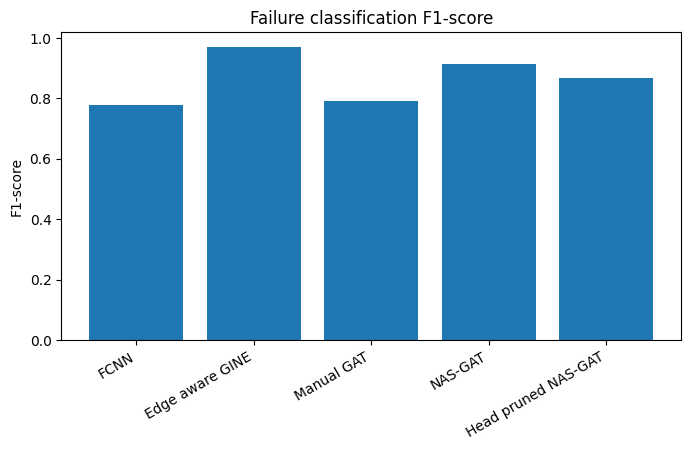

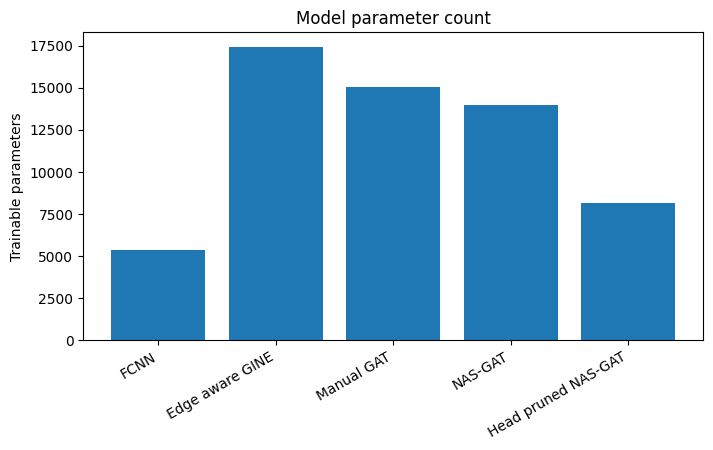

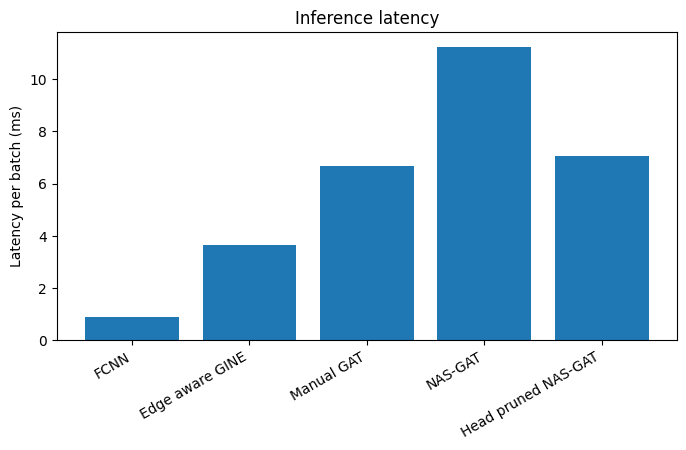

In [51]:
# Final plots

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["f1"])
plt.title("Failure classification F1-score")
plt.ylabel("F1-score")
plt.xticks(rotation=30, ha="right")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["parameters"])
plt.title("Model parameter count")
plt.ylabel("Trainable parameters")
plt.xticks(rotation=30, ha="right")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["latency_ms"])
plt.title("Inference latency")
plt.ylabel("Latency per batch (ms)")
plt.xticks(rotation=30, ha="right")
plt.show()

## 18. Confusion matrix

False negatives are important in this project because they mean the monitoring system missed a dangerous case.

Confusion matrix for: Edge aware GINE


,Pred no cascade,Pred cascade
True no cascade,2565,10
True cascade,28,622


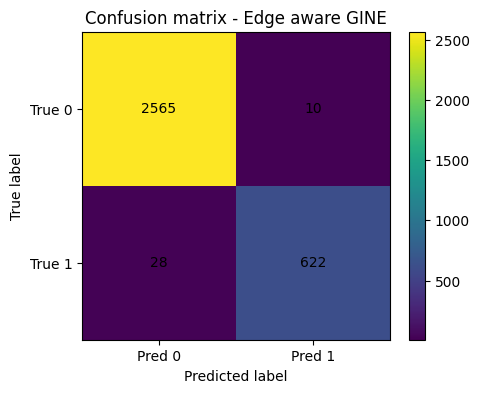

In [52]:
# Confusion matrix for best F1 model


prediction_objects = {"FCNN": fcnn_pred,
    "Edge aware GINE": gcn_pred,
    "Manual GAT": manual_gat_pred,
    "NAS-GAT": nas_gat_pred,
    "Head-pruned NAS-GAT": pruned_gat_pred, }

best_model_name = comparison_df.sort_values("f1", ascending=False).iloc[0]["model"]
final_pred = prediction_objects[best_model_name]

print("Confusion matrix for:", best_model_name)

cm = confusion_matrix(final_pred["true_class"], final_pred["pred_class"])

cm_df = pd.DataFrame(cm, index=["True no cascade", "True cascade"], columns=["Pred no cascade", "Pred cascade"], )

display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion matrix - {best_model_name}")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

## 19. Regression Results

In [53]:
# ============================================================
# DNS severity regression results
# MAE, RMSE, and R2 by model
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Use the existing project results table
# If this cell is placed after the latest final comparison table,
# it will use the latest DNS results.
dns_results_df = comparison_df.copy()

# Keep only the DNS-related metrics
dns_results_df = dns_results_df[
    [
        "model",
        "mae_dns",
        "rmse_dns",
        "r2_dns",
        "parameters",
        "latency_ms",
    ]
].copy()

# Sort by MAE because lower MAE means better DNS prediction
dns_results_df = dns_results_df.sort_values("mae_dns", ascending=True)

display(dns_results_df)

print("DNS interpretation:")
print("- MAE DNS: lower is better.")
print("- RMSE DNS: lower is better.")
print("- R2 DNS: higher is better.")

,model,mae_dns,rmse_dns,r2_dns,parameters,latency_ms
1,Edge aware GINE,0.009541,0.041335,0.211433,17430,3.649076
4,Head pruned NAS-GAT,0.011868,0.044027,0.105353,8162,7.044036
2,Manual GAT,0.012095,0.044931,0.068247,15042,6.672521
0,FCNN,0.013187,0.043705,0.118402,5378,0.888879
3,NAS-GAT,0.017059,0.044024,0.105489,13986,11.252085


DNS interpretation:
- MAE DNS: lower is better.
- RMSE DNS: lower is better.
- R2 DNS: higher is better.


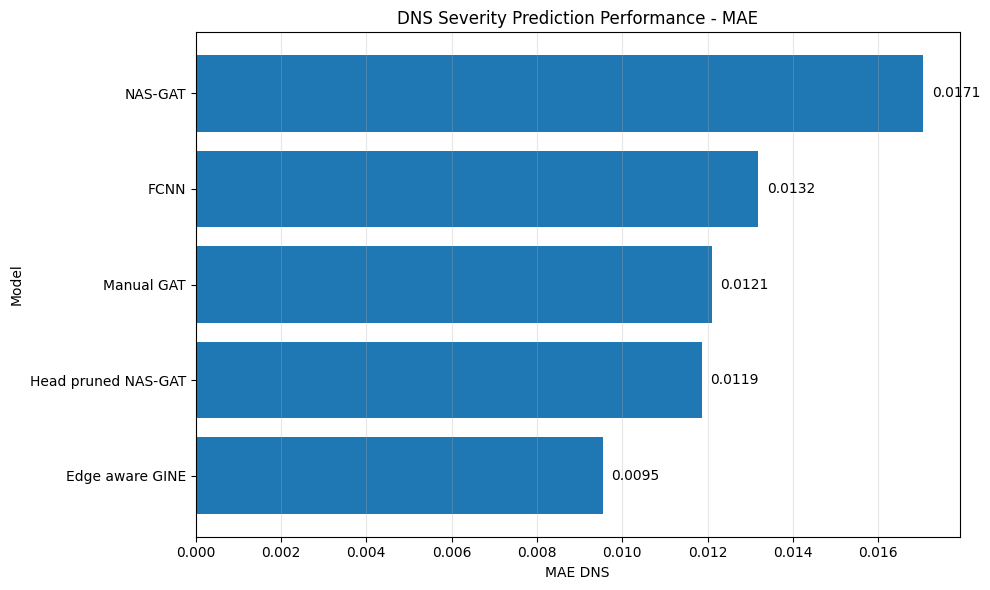

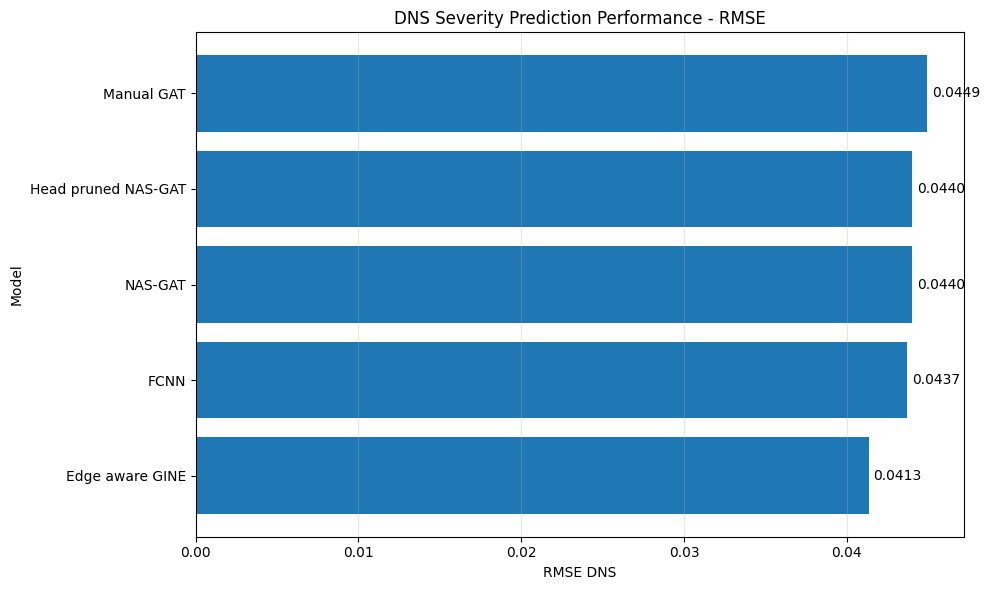

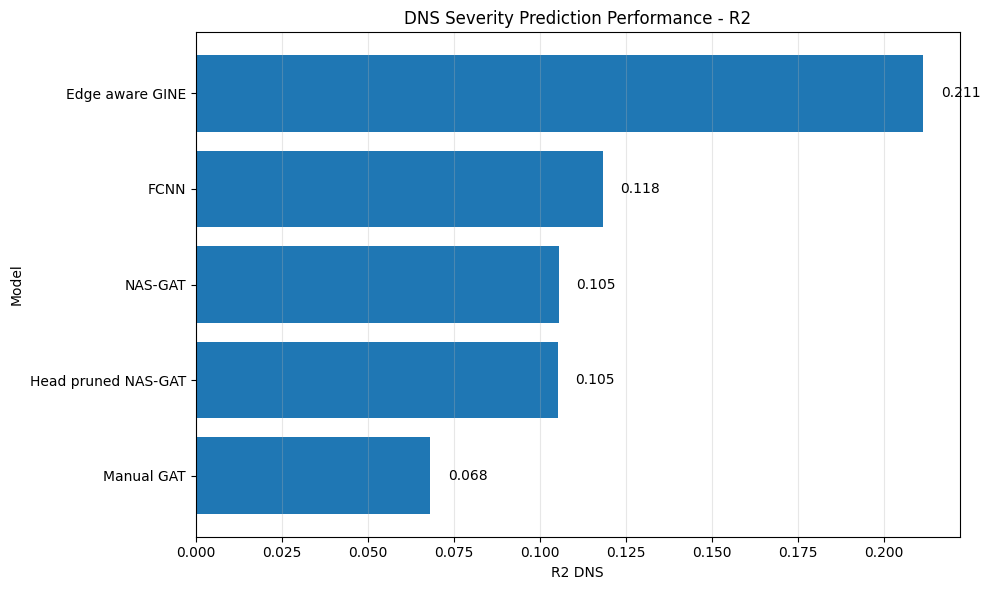

In [54]:
# ============================================================
# Save DNS severity regression plots for presentation
# ============================================================

# -----------------------------
# 1. MAE DNS plot
# -----------------------------
plt.figure(figsize=(10, 6))

plot_df = dns_results_df.sort_values("mae_dns", ascending=True)

bars = plt.barh(
    plot_df["model"],
    plot_df["mae_dns"]
)

plt.xlabel("MAE DNS")
plt.ylabel("Model")
plt.title("DNS Severity Prediction Performance - MAE")

plt.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center"
    )

plt.tight_layout()
plt.savefig("dns_mae_by_model.jpg", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 2. RMSE DNS plot
# -----------------------------
plt.figure(figsize=(10, 6))

plot_df = dns_results_df.sort_values("rmse_dns", ascending=True)

bars = plt.barh(
    plot_df["model"],
    plot_df["rmse_dns"]
)

plt.xlabel("RMSE DNS")
plt.ylabel("Model")
plt.title("DNS Severity Prediction Performance - RMSE")

plt.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center"
    )

plt.tight_layout()
plt.savefig("dns_rmse_by_model.jpg", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 3. R2 DNS plot
# -----------------------------
plt.figure(figsize=(10, 6))

plot_df = dns_results_df.sort_values("r2_dns", ascending=True)

bars = plt.barh(
    plot_df["model"],
    plot_df["r2_dns"]
)

plt.xlabel("R2 DNS")
plt.ylabel("Model")
plt.title("DNS Severity Prediction Performance - R2")

plt.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.savefig("dns_r2_by_model.jpg", dpi=300, bbox_inches="tight")
plt.show()

## 20. Attention based intepretability

I inspect the attention weights from manual GAT. The idea is to see weather high attention edges overlap with the ground truth failure explanation mask

In [ ]:
# Attention analysis

@torch.no_grad()
def analyze_attention_for_one_graph(model, graph):
    model.eval()
    model = model.to(device)

    batch = next(iter(DataLoader([graph], batch_size=1, shuffle=False))).to(device)
    class_logit, reg_log, attention_outputs = model(batch, return_attention=True)

    edge_index_att, alpha = attention_outputs[-1]
    alpha_mean = alpha.mean(dim=1).detach().cpu().numpy()
    edge_index_np = edge_index_att.detach().cpu().numpy()
    edge_mask_np = batch.edge_mask.detach().cpu().numpy()

    n = min(len(alpha_mean), len(edge_mask_np))

    df = pd.DataFrame({
        "from_bus": edge_index_np[0, :n] + 1,
        "to_bus": edge_index_np[1, :n] + 1,
        "attention": alpha_mean[:n],
        "groundtruth_failed_edge": edge_mask_np[:n].astype(int),
    }).sort_values("attention", ascending=False).reset_index(drop=True)

    pred_prob = torch.sigmoid(class_logit).item()
    pred_dns = torch.expm1(reg_log).clamp(min=0).item()
    return df, pred_prob, pred_dns

cascade_test_graphs = [g for g in test_graphs if g.y_class.item() == 1]
graph_to_explain = cascade_test_graphs[0] if len(cascade_test_graphs) > 0 else test_graphs[0]

attention_df, pred_prob, pred_dns = analyze_attention_for_one_graph(manual_gat, graph_to_explain)

print("True class:", graph_to_explain.y_class.item())
print("True DNS:", graph_to_explain.y_reg.item())
print("Predicted cascade probability:", round(pred_prob, 4))
print("Predicted DNS:", round(pred_dns, 4))

display(attention_df.head(15))

True class: 1
True DNS: 0.04771929979324341
Predicted cascade probability: 0.5253
Predicted DNS: 0.015


,from_bus,to_bus,attention,groundtruth_failed_edge
0,8,7,1.000000,0
1,6,2,1.000000,0
2,10,8,1.000000,0
3,2,4,0.999999,0
4,2,6,0.999667,0
5,17,18,0.999041,0
6,16,14,0.999037,0
7,10,5,0.999037,0
8,17,22,0.992707,0
9,17,16,0.978423,0


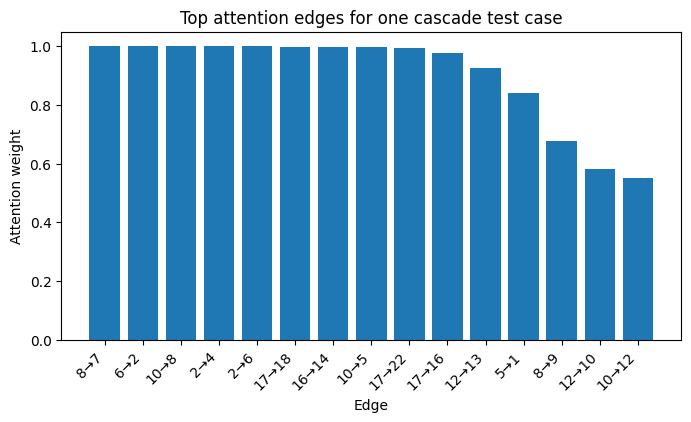

{'top_k': 5, 'failed_edges_in_top_k': 0, 'overlap_ratio': 0.0}
{'top_k': 10, 'failed_edges_in_top_k': 0, 'overlap_ratio': 0.0}
{'top_k': 20, 'failed_edges_in_top_k': 0, 'overlap_ratio': 0.0}


In [ ]:
# Plotting top attention edges and overlap with explanation mask

top_k = 15
top_edges = attention_df.head(top_k).copy()
top_edges["edge"] = top_edges["from_bus"].astype(str) + "→" + top_edges["to_bus"].astype(str)

plt.figure(figsize=(8, 4))
plt.bar(top_edges["edge"], top_edges["attention"])
plt.title("Top attention edges for one cascade test case")
plt.xlabel("Edge")
plt.ylabel("Attention weight")
plt.xticks(rotation=45, ha="right")
plt.show()

def attention_explanation_overlap(attention_df, k=20):
    top = attention_df.head(k)
    overlap = top["groundtruth_failed_edge"].sum()
    return {
        "top_k": k,
        "failed_edges_in_top_k": int(overlap),
        "overlap_ratio": float(overlap / k),
    }

for k in [5, 10, 20]:
    print(attention_explanation_overlap(attention_df, k=k))